### Intent Classification for Underrepresented Languages

In this notebook we are going to investigate how do a local-pattern CNN and a sequential LSTM compare within each language in accuracy, macro precision, macro recall, macro F1, model size and inference latency. Word masking will explore which token positions influence each prediction. These are reproducible baselines, not claims of state-of-the-art performance.

| Language | CNN experiment | LSTM experiment |
|---|---|---|
| English | eng_CNN | eng_LSTM |
| isiXhosa | xho_CNN | xho_LSTM |
| isiZulu | zul_CNN | zul_LSTM |
| Sesotho | sot_CNN | sot_LSTM |


In [1]:
# %pip install --upgrade --only-binary=:all: "torch>=2.10" numpy pandas matplotlib scikit-learn ipykernel pigmenta

### Import packages
In the following code cell we are going to load the data, plotting and PyTorch packages, including Pigmenta.


In [2]:
import sys, os, re, json, time, random, hashlib, unicodedata, platform
from pathlib import Path
from collections import Counter
from urllib.request import urlopen, Request
from urllib.error import HTTPError
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pigmenta import PALETTES
from cycler import cycler
import torch
from torch import nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from IPython.display import display


### Experiment configuration
In the following code cell we are going to set the four languages, shared hyperparameters, output folders and device.


In [3]:
LANGUAGES = {'eng': 'English', 'xho': 'isiXhosa', 'zul': 'isiZulu', 'sot': 'Sesotho'}
SEED = 3399
CFG = dict(embedding_dim=128, hidden_dim=128, filters=128, kernels=[3, 4, 5],
           dropout=0.3, batch_size=64, epochs=25, patience=5, lr=0.001,
           weight_decay=0.0001, max_vocab=30000, min_freq=1, max_length_cap=128,
           validation_fraction=0.2, use_class_weights=True)
OUT = Path('injongo_results'); OUT.mkdir(exist_ok=True)
CACHE = Path('injongo_data'); CACHE.mkdir(exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Reproducibility helper
In the following code cell we are going to define how random seeds and deterministic cuDNN settings are applied.


In [4]:
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### Initialize seeds and record the environment
In the following code cell we are going to save the configuration and package versions for this run.

In [5]:
seed_everything()
versions = {'python': sys.version, 'torch': torch.__version__, 'numpy': np.__version__,
            'pandas': pd.__version__, 'platform': platform.platform(), 'device': str(DEVICE)}
print(versions)
print('Seeds reduce variability; bitwise agreement across hardware is not guaranteed.')
(OUT / 'configuration.json').write_text(json.dumps({'config': CFG, 'seed': SEED, 'versions': versions}, indent=2))


{'python': '3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]', 'torch': '2.9.0+cu126', 'numpy': '2.4.6', 'pandas': '2.3.3', 'platform': 'Windows-11-10.0.26200-SP0', 'device': 'cuda'}
Seeds reduce variability; bitwise agreement across hardware is not guaranteed.


670

### Set palette and plotting defaults
In the following code cell we are going to set the default ploting color theme for the notebook.

In [6]:
NATURE = list(PALETTES.nature)
MODEL_COLORS = {'CNN': NATURE[0], 'LSTM': NATURE[2]}
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 120,
                     'figure.figsize': (9, 5), 'axes.grid': True,
                     'axes.axisbelow': True,
                     'axes.prop_cycle': cycler(color=NATURE),
                     'axes.spines.top': False, 'axes.spines.right': False})


In [7]:
def finish(fig, filename):
    for ax in fig.axes:
        ax.minorticks_on()
        ax.set_axisbelow(True)
        ax.grid(which='major', color='gray', linestyle='-', linewidth=0.5, alpha=1.0)
        ax.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3, alpha=1.0)
    for ax in fig.axes:
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles, labels, loc='upper center',
                      bbox_to_anchor=(0.5, -0.25), ncol=3, borderaxespad=0.)
    fig.tight_layout()
    fig.savefig(OUT / (filename + '.png'), dpi=120, bbox_inches='tight')
    plt.show()

### Dataset loading and provenance

> [INJONGO (Yu et al., 2025)](https://aclanthology.org/2025.acl-long.464/) is a multicultural intent-detection and slot-filling benchmark for African languages. This notebook uses the [Masakhane InjongoIntent distribution](https://huggingface.co/datasets/masakhane/InjongoIntent), including its English configuration. Only utterance text and intent are model inputs/targets; slot annotations and domains are not features.

The configuration lists `train.jsonl`, `dev.jsonl`, `test.jsonl` for the 3 African languages and only train/test for English. The loader reads actual records, checks their schema, and reports actual counts rather than trusting the card's inconsistent example/count text.

In [8]:
REPO = 'masakhane/InjongoIntent'
REVISION = 'main'
manifest = []


### Download and cache JSONL files
In the following code cell we are going to read one JSON object per line and record each file hash.

In [9]:
def read_jsonl(lang, filename, optional=False):
    path = CACHE / REVISION / lang / filename
    url = f'https://huggingface.co/datasets/{REPO}/resolve/{REVISION}/{lang}/{filename}'
    if not path.exists():
        try:
            with urlopen(Request(url, headers={'User-Agent': 'INJONGO-notebook'}), timeout=60) as response:
                data = response.read()
        except HTTPError as exc:
            if optional and exc.code == 404: return None
            raise
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_bytes(data)
    data = path.read_bytes()
    records = [json.loads(line) for line in data.decode('utf-8-sig').splitlines() if line.strip()]
    if not records or not all(isinstance(row, dict) for row in records):
        raise ValueError(f'{path}: expected nonempty JSON objects, one per line')
    manifest.append(dict(language=lang, file=filename, url=url, sha256=hashlib.sha256(data).hexdigest()))
    return pd.DataFrame.from_records(records)


### Standardize text and intent fields
In the following code cell we are going to check the schema and report missing records.


In [10]:
def standardize(df, lang, split):
    text_col = next((k for k in ['text', 'raw', 'utterance', 'sentence'] if k in df), None)
    label_col = next((k for k in ['intent', 'label'] if k in df), None)
    if text_col is None or label_col is None:
        raise ValueError(f'{lang}/{split}: unsupported columns {list(df.columns)}')
    df = df[[text_col, label_col]].rename(columns={text_col: 'text', label_col: 'intent'}).copy()
    missing = df.isna().any(axis=1)
    print(lang, split, 'missing rows removed:', int(missing.sum()))
    df = df.loc[~missing].copy()
    if not df.text.map(lambda x: isinstance(x, str)).all():
        raise TypeError('Utterances must be strings; inspect source schema.')
    if not df.intent.map(lambda x: isinstance(x, (str, int, np.integer))).all():
        raise TypeError('Expected one scalar intent per utterance.')
    df['intent'] = df.intent.astype(str)
    df['source_row'] = df.index
    return df.reset_index(drop=True)


In [11]:
def load_language(lang):
    tables = {}
    for split, filename in [('train', 'train.jsonl'), ('validation', 'dev.jsonl'), ('test', 'test.jsonl')]:
        df = read_jsonl(lang, filename, optional=(lang == 'eng' and split == 'validation'))
        if df is not None: tables[split] = standardize(df, lang, split)
    return tables


### Load the four languages
In the following code cell we are going to download the datasets, save provenance and inspect the actual counts.


In [12]:
raw_data = {lang: load_language(lang) for lang in LANGUAGES}
(OUT / 'data_manifest.json').write_text(json.dumps(manifest, indent=2))
display(pd.DataFrame([dict(language=l, split=s, rows=len(d)) for l,t in raw_data.items() for s,d in t.items()]))
display(raw_data['eng']['train'].head())


eng train missing rows removed: 0
eng test missing rows removed: 0
xho train missing rows removed: 0
xho validation missing rows removed: 0
xho test missing rows removed: 0
zul train missing rows removed: 0
zul validation missing rows removed: 0
zul test missing rows removed: 0
sot train missing rows removed: 0
sot validation missing rows removed: 0
sot test missing rows removed: 0


,language,split,rows
0,eng,train,1779
1,eng,test,622
2,xho,train,2240
3,xho,validation,320
4,xho,test,640
5,zul,train,2240
6,zul,validation,320
7,zul,test,640
8,sot,train,2240
9,sot,validation,320


,text,intent,source_row
0,"how do I say ""I want to use the bus"" in Oromo ...",translate,0
1,Can you transfer 50000 birr from my commercial...,transfer,1
2,what time is it in Addis Ababa,time,2
3,Add teff to the groceries list.,shopping_list_update,3
4,Can you reserve a dinner place for me at Totot...,restaurant_reservation,4


### Cleaning and split integrity
We will use Unicode NFC normalization, lowercase and whitespace normalization. We retain digits, negation and accented characters. Tokenization keeps Unicode word characters and internal apostrophes. It is deliberately simple; word-level vocabulary can fragment coverage in morphologically rich languages.

In [13]:
def clean_text(text):
    return ' '.join(unicodedata.normalize('NFC', text).lower().split())
def tokenize(text):
    return re.findall(r"\w+(?:['’]\w+)*", clean_text(text), flags=re.UNICODE)


### Prepare splits and audit duplicate texts
In the following code cell we are going to apply the existing split-integrity checks and save the resulting split records.


In [14]:
data, audits = {}, []
for lang, tables in raw_data.items():
    cleaned = {}
    for split, df in tables.items():
        df = df.copy(); df['clean'] = df.text.map(clean_text)
        keep = df.clean.map(lambda x: len(tokenize(x)) > 0)
        print(lang, split, 'empty token rows removed:', int((~keep).sum()))
        cleaned[split] = df.loc[keep].reset_index(drop=True)
    combined = pd.concat(cleaned.values())
    bad = combined.groupby('clean').intent.nunique()
    if (bad > 1).any():
        raise ValueError(f'{lang}: conflicting labels for identical cleaned text; inspect before proceeding')
    if 'validation' not in cleaned:
        groups = cleaned['train'].drop_duplicates('clean')
        if groups.intent.value_counts().min() < 2:
            raise ValueError('Insufficient unique examples for stratified validation')
        tr, va = train_test_split(groups, test_size=CFG['validation_fraction'],
                                  random_state=SEED, stratify=groups.intent)
        original = cleaned['train']
        cleaned['train'] = original[original.clean.isin(set(tr.clean))].reset_index(drop=True)
        cleaned['validation'] = original[original.clean.isin(set(va.clean))].reset_index(drop=True)
        print(lang, 'created grouped, stratified validation from training')
    for split, df in cleaned.items():
        audits.append(dict(language=lang, check=f'{split} duplicate texts', count=int(df.clean.duplicated().sum())))
    for a,b in [('train','validation'), ('train','test'), ('validation','test')]:
        n = len(set(cleaned[a].clean) & set(cleaned[b].clean))
        audits.append(dict(language=lang, check=f'{a}/{b} shared texts', count=n))
        if n: print(f'WARNING: {lang} {a}/{b} share {n} cleaned texts; qualify benchmark scores.')
    train_labels = set(cleaned['train'].intent)
    for split in ['validation','test']:
        unseen = set(cleaned[split].intent) - train_labels
        if unseen: raise ValueError(f'{lang}/{split} has labels absent from training: {unseen}')
    data[lang] = cleaned
    for split, df in cleaned.items():
        df[['source_row','text','intent']].to_csv(OUT / f'{lang}_{split}_split.csv', index=False)


eng train empty token rows removed: 0
eng test empty token rows removed: 0
eng created grouped, stratified validation from training
xho train empty token rows removed: 0
xho validation empty token rows removed: 0
xho test empty token rows removed: 0
zul train empty token rows removed: 0
zul validation empty token rows removed: 0
zul test empty token rows removed: 0
sot train empty token rows removed: 0
sot validation empty token rows removed: 0
sot test empty token rows removed: 0


### Inspect the data audit
In the following code cell we are going to review duplicate and shared-text counts before training.


In [15]:
display(pd.DataFrame(audits))
pd.DataFrame(audits).to_csv(OUT / 'data_audit.csv', index=False)


,language,check,count
0,eng,train duplicate texts,0
1,eng,test duplicate texts,0
2,eng,validation duplicate texts,0
3,eng,train/validation shared texts,0
4,eng,train/test shared texts,499
5,eng,validation/test shared texts,123
6,xho,train duplicate texts,1
7,xho,validation duplicate texts,0
8,xho,test duplicate texts,0
9,xho,train/validation shared texts,0


### Exploratory data analysis
In the following code cell we are going to inspect split sizes, training intent balance and token lengths before modeling. These observations must not be used to tune models against the test outcomes. 

In [16]:
counts = pd.DataFrame([dict(language=l, split=s, rows=len(d), intents=d.intent.nunique())
                      for l,t in data.items() for s,d in t.items()])
display(counts)

,language,split,rows,intents
0,eng,train,1423,40
1,eng,test,622,40
2,eng,validation,356,40
3,xho,train,2240,40
4,xho,validation,320,40
5,xho,test,640,40
6,zul,train,2240,40
7,zul,validation,320,40
8,zul,test,640,40
9,sot,train,2240,40


### Plot split sizes
In the following code cell we are going to compare the number of training, validation and test utterances.


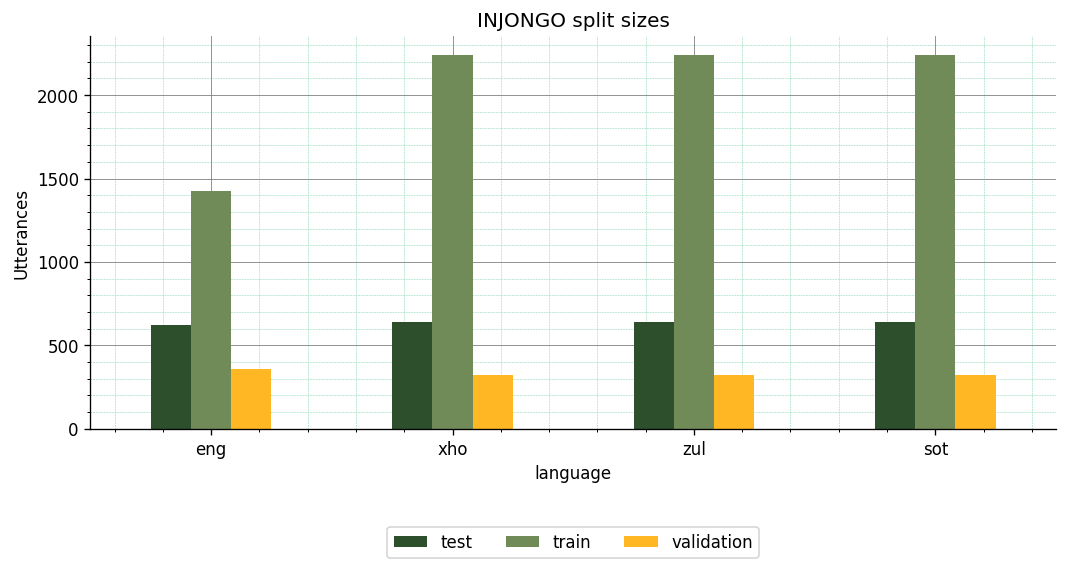

In [17]:
fig, ax = plt.subplots()
counts.pivot(index='language', columns='split', values='rows').reindex(LANGUAGES).plot.bar(ax=ax, rot=0)
ax.set(ylabel='Utterances', title='INJONGO split sizes'); finish(fig, 'split_sizes')


### Plot training token lengths
 In the following code cell we are going to inspect the training length distribution for each language.


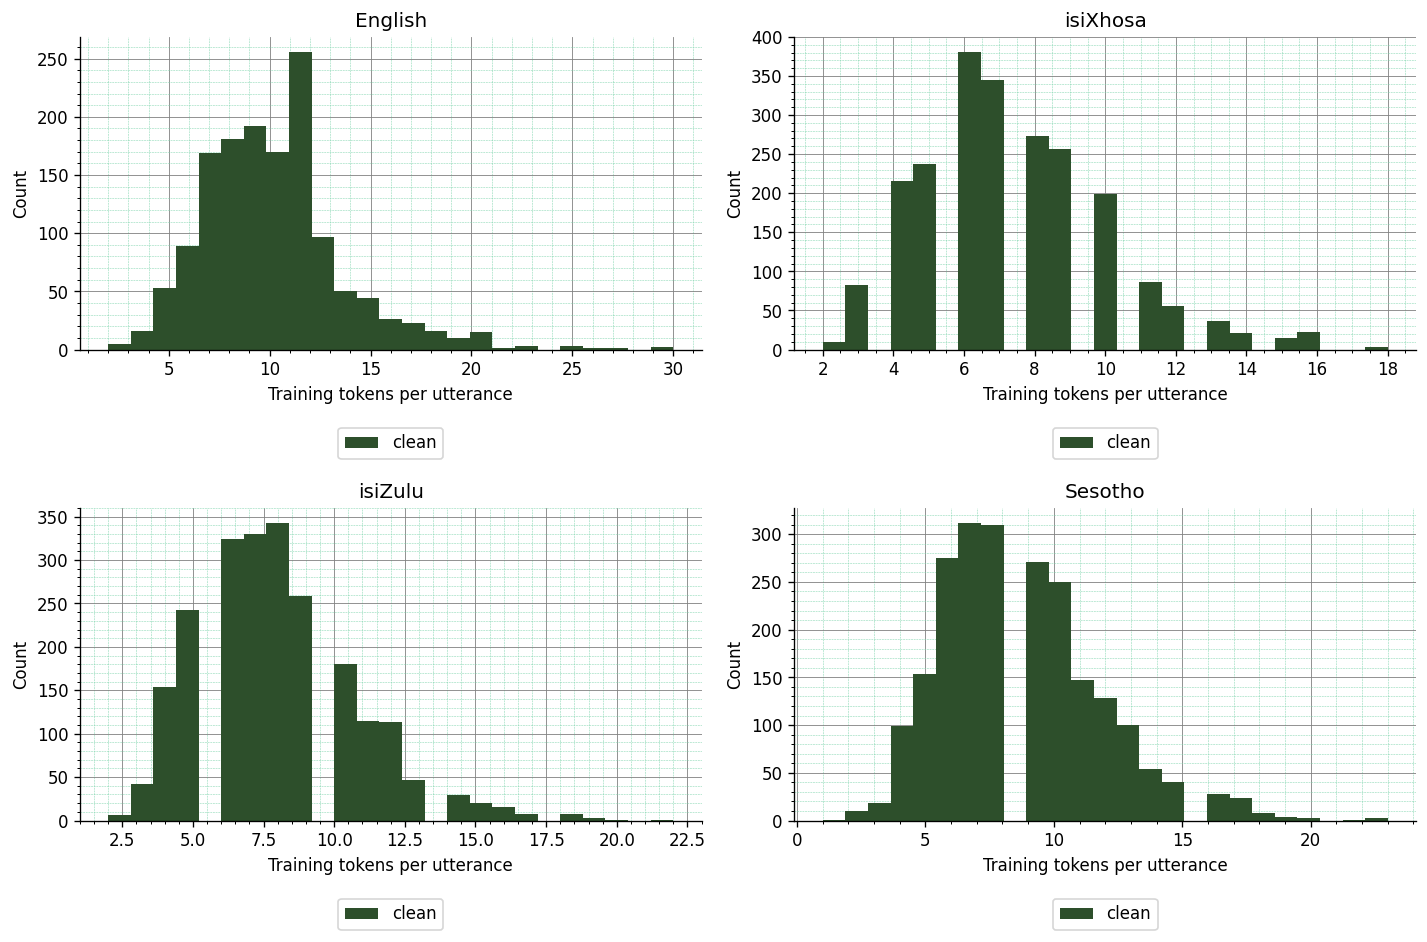

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for (lang, tables), ax in zip(data.items(), axes.flat):
    tables['train'].clean.map(lambda x: len(tokenize(x))).plot.hist(bins=25, ax=ax, color=NATURE[0])
    ax.set(title=LANGUAGES[lang], xlabel='Training tokens per utterance', ylabel='Count')
finish(fig, 'training_lengths')


### Plot frequent training intents
In the following code cell we are going to compare counts for the 15 most frequent intents in each language.


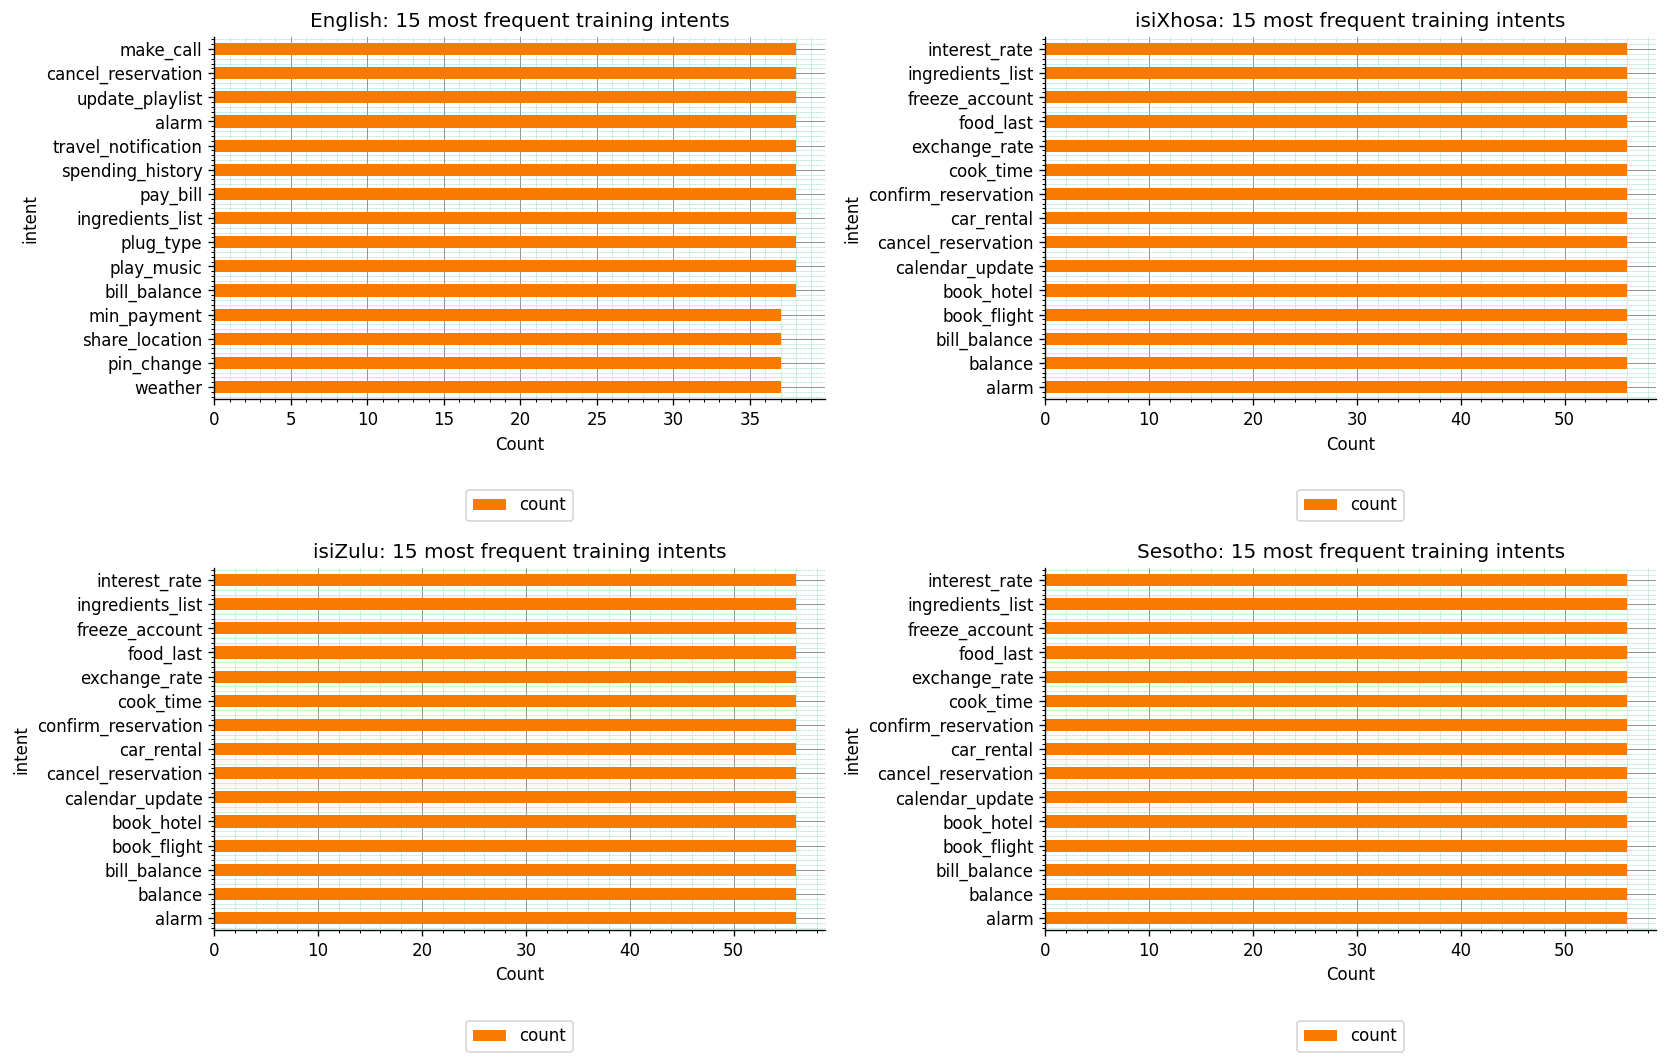

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for (lang, tables), ax in zip(data.items(), axes.flat):
    tables['train'].intent.value_counts().head(15).sort_values().plot.barh(ax=ax, color=NATURE[6])
    ax.set(title=f'{LANGUAGES[lang]}: 15 most frequent training intents', xlabel='Count')
finish(fig, 'training_intents')


### Vocabulary, encoding and class weights
Each language has a separate training-only vocabulary and label mapping shared by its two architectures. `<PAD>` is index 0 and `<UNK>` is index 1. The sequence limit is the training `95th` percentile, capped at 128 and at least the largest CNN kernel. We will report unknown-token and truncation rates to interpret language differences. For class $c$, balanced training weights are:
$$
w_c = \frac{N}{C n_c}
$$
Here $N$ is the training sample count, $C$ the number of training classes and $n_c$ the training count of class $c$. Validation and test counts do not enter this formula. Both models use the same optional weights. An embedding matrix maps each token ID to a learned dense vector:
$$
E \in \mathbb{R}^{V\times d}, \qquad x_t=E[\mathrm{id}(w_t)]
$$
$V$ is vocabulary size and $d$ is embedding dimension. Padding has a fixed zero embedding; unknown words share a learned embedding. These are word-level baselines, not pretrained language models.


### Build training-only vocabularies and weights
In the following code cell we are going to prepare a separate vocabulary, label mapping and length limit for each language.


In [20]:
artifacts, coverage = {}, []
for lang, tables in data.items():
    train = tables['train']
    freq = Counter(token for text in train.clean for token in tokenize(text))
    words = [w for w,n in sorted(freq.items(), key=lambda p: (-p[1],p[0])) if n >= CFG['min_freq']]
    vocab = {'<PAD>': 0, '<UNK>': 1}
    vocab.update({w:i+2 for i,w in enumerate(words[:CFG['max_vocab']-2])})
    labels = sorted(train.intent.unique()); label_to_id = {name:i for i,name in enumerate(labels)}
    lengths = train.clean.map(lambda s: len(tokenize(s)))
    max_len = max(max(CFG['kernels']), min(CFG['max_length_cap'], int(np.ceil(np.quantile(lengths, .95)))))
    nums = train.intent.value_counts().reindex(labels).to_numpy()
    weights = torch.tensor(len(train) / (len(labels)*nums), dtype=torch.float32)
    artifacts[lang] = dict(vocab=vocab, labels=labels, label_to_id=label_to_id, max_len=max_len, weights=weights)
    for split, df in tables.items():
        seqs = [tokenize(s) for s in df.clean]
        coverage.append(dict(language=lang, split=split, vocab=len(vocab), max_len=max_len,
            unk_rate=sum(w not in vocab for seq in seqs for w in seq)/sum(map(len,seqs)),
            truncation_rate=np.mean([len(seq)>max_len for seq in seqs])))
    (OUT / f'{lang}_preprocessing.json').write_text(json.dumps(
        dict(vocab=vocab, labels=labels, max_len=max_len, config=CFG), ensure_ascii=False, indent=2), encoding='utf-8')


### Inspect vocabulary coverage
In the following code cell we are going to display and save unknown-token and truncation rates.


In [21]:
display(pd.DataFrame(coverage).round(4))
pd.DataFrame(coverage).to_csv(OUT / 'coverage.csv', index=False)


,language,split,vocab,max_len,unk_rate,truncation_rate
0,eng,train,2387,17,0.0000,0.0365
1,eng,test,2387,17,0.0184,0.0418
2,eng,validation,2387,17,0.0956,0.0337
3,xho,train,3805,12,0.0000,0.0438
4,xho,validation,3805,12,0.1238,0.0500
5,xho,test,3805,12,0.1372,0.0500
6,zul,train,5635,13,0.0000,0.0375
7,zul,validation,5635,13,0.2230,0.0469
8,zul,test,5635,13,0.2227,0.0406
9,sot,train,2476,14,0.0000,0.0496


### Encode the dataset
In the following code cell we are going to map utterance tokens and intent labels to integer tensors.


In [22]:
class IntentDataset(Dataset):
    def __init__(self, df, art):
        self.items = [(torch.tensor([art['vocab'].get(w,1) for w in tokenize(s)[:art['max_len']]], dtype=torch.long),
                       art['label_to_id'][y]) for s,y in zip(df.clean, df.intent)]
    def __len__(self): return len(self.items)
    def __getitem__(self, index): return self.items[index]


### Pad a batch
In the following code cell we are going to retain true sequence lengths and support the largest CNN kernel.


In [23]:
def collate(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in sequences], dtype=torch.long)
    x = pad_sequence(sequences, batch_first=True, padding_value=0)
    if x.shape[1] < max(CFG['kernels']):
        x = nn.functional.pad(x, (0,max(CFG['kernels'])-x.shape[1]))
    return x, lengths, torch.tensor(labels, dtype=torch.long)


### Create data loaders
Use the same seeded batch order for each architecture, with Windows-safe worker settings.


In [24]:
def make_loaders(lang):
    gen = torch.Generator().manual_seed(SEED)
    return {split: DataLoader(IntentDataset(df, artifacts[lang]), batch_size=CFG['batch_size'],
                shuffle=(split=='train'), generator=gen if split=='train' else None,
                collate_fn=collate, num_workers=0)
            for split,df in data[lang].items()}


### Models

#### 1. CNN: local patterns with masked global max pooling
For a window of $k$ embeddings and filter $j$:
$$
a_{t,j}^{(k)} = \operatorname{ReLU}\left(\langle W_j^{(k)},X_{t:t+k-1}\rangle+b_j^{(k)}\right),
\qquad h_j^{(k)}=\max_{t\in\mathcal V_k}a_{t,j}^{(k)}
$$
$\mathcal V_k$ contains valid window starts. With sequence length $L$, use $\max(1,L-k+1)$ windows: a short utterance gets one zero-padded window, and extra batch padding cannot dominate pooling. Concatenate pooled features from kernels 3, 4 and 5, apply dropout, then a linear classifier.

#### 2. LSTM: sequential memory
For embedding $x_t$, previous hidden state $h_{t-1}$ and cell state $c_{t-1}$:
$$
i_t=\sigma(W_i[x_t;h_{t-1}]+b_i),\quad
f_t=\sigma(W_f[x_t;h_{t-1}]+b_f)
$$
$$
g_t=\tanh(W_g[x_t;h_{t-1}]+b_g),\quad
o_t=\sigma(W_o[x_t;h_{t-1}]+b_o)
$$
$$
c_t=f_t\odot c_{t-1}+i_t\odot g_t,\qquad
h_t=o_t\odot\tanh(c_t)
$$
The input gate $i_t$ controls new information, forget gate $f_t$ retained memory, and output gate $o_t$ exposed memory. $\odot$ means elementwise multiplication. A single **unidirectional LSTM** uses its final real-token hidden state, dropout and a linear classifier. Packed sequences exclude trailing padding.

The two models use equal embedding dimension, dropout, optimizer, split, seed and training budget. Parameter counts differ by architecture and are reported; this is not a parameter-matched study.


### CNN
Learn local token patterns and pool only valid convolution windows.


In [25]:
class CNN(nn.Module):
    def __init__(self, vocab_size, n_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, CFG['embedding_dim'], padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(CFG['embedding_dim'], CFG['filters'], k) for k in CFG['kernels']])
        self.dropout = nn.Dropout(CFG['dropout'])
        self.fc = nn.Linear(CFG['filters']*len(CFG['kernels']), n_classes)
    def forward(self, x, lengths):
        emb = self.embedding(x).transpose(1,2)
        pooled = []
        for conv,k in zip(self.convs, CFG['kernels']):
            features = torch.relu(conv(emb))
            valid = (lengths.to(x.device)-k+1).clamp(min=1)
            positions = torch.arange(features.shape[2], device=x.device)
            mask = positions[None,:] >= valid[:,None]
            pooled.append(features.masked_fill(mask[:,None,:], float('-inf')).amax(dim=2))
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))


### LSTM
Process packed sequences and classify the final real-token hidden state.


In [26]:
class LSTM(nn.Module):
    def __init__(self, vocab_size, n_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, CFG['embedding_dim'], padding_idx=0)
        self.lstm = nn.LSTM(CFG['embedding_dim'], CFG['hidden_dim'], batch_first=True)
        self.dropout = nn.Dropout(CFG['dropout'])
        self.fc = nn.Linear(CFG['hidden_dim'], n_classes)
    def forward(self, x, lengths):
        packed = pack_padded_sequence(self.embedding(x), lengths.cpu(), batch_first=True, enforce_sorted=False)
        _,(hidden,_) = self.lstm(packed)
        return self.fc(self.dropout(hidden[-1]))


### Create an experiment model
In the following code cell we are going to select the architecture and the relevant language vocabulary.


In [27]:
MODEL_CLASSES = {'CNN': CNN, 'LSTM': LSTM}
def new_model(lang, name):
    art = artifacts[lang]
    return MODEL_CLASSES[name](len(art['vocab']),len(art['labels'])).to(DEVICE)


#### Training objective, evaluation metrics and checkpoint selection
Logits $z_c$ become probabilities through softmax:
$$
p_c=\frac{\exp(z_c)}{\sum_{j=1}^{C}\exp(z_j)},\qquad \hat y=\arg\max_c p_c
$$
PyTorch cross entropy receives **raw logits**, not probabilities. Weighted batch loss is:
$$
\mathcal L=-\frac{\sum_{i=1}^{B}w_{y_i}\log p_{i,y_i}}{\sum_{i=1}^{B}w_{y_i}}
$$
Set weights to one for ordinary cross entropy. Epoch loss below accumulates weighted numerators and denominators across batches, avoiding an incorrect average of batch means.

$$
\mathrm{Accuracy}=\frac{1}{N}\sum_i\mathbf1[\hat y_i=y_i]
$$
$$
P_c=\frac{TP_c}{TP_c+FP_c},\quad R_c=\frac{TP_c}{TP_c+FN_c},\quad
F1_c=\frac{2P_cR_c}{P_c+R_c}
$$
$$
P_{macro}=\frac1C\sum_c P_c,\quad R_{macro}=\frac1C\sum_c R_c,\quad
F1_{macro}=\frac1C\sum_c F1_c
$$
Undefined divisions contribute zero. Macro F1 averages classwise F1, not the harmonic mean of macro precision/recall. Select each checkpoint by **highest validation macro F1**, with validation loss as an exact-tie breaker. Stop after five non-improving epochs; do not choose checkpoints or hyperparameters using test scores. Gradient clipping limits the norm to 1.0.


### Calculate classification metrics
In the following code cell we are going to compute accuracy and macro-averaged precision, recall and F1.


In [28]:
def metric_values(y, pred, n_classes):
    p,r,f,_ = precision_recall_fscore_support(y,pred,labels=list(range(n_classes)),average='macro',zero_division=0)
    return dict(accuracy=accuracy_score(y,pred), precision_macro=p, recall_macro=r, f1_macro=f)


### Run one training or evaluation epoch
Accumulate the weighted loss correctly and collect predictions.


In [29]:
def run_epoch(model, loader, weights, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, denominator, ys, preds = 0.,0.,[],[]
    with torch.set_grad_enabled(training):
        for x,lengths,y in loader:
            x,y = x.to(DEVICE),y.to(DEVICE)
            logits = model(x,lengths)
            loss_sum = nn.functional.cross_entropy(logits,y,weight=weights,reduction='sum')
            denom = weights[y].sum() if weights is not None else y.new_tensor(y.numel())
            loss = loss_sum/denom
            if training:
                optimizer.zero_grad(set_to_none=True); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
            total_loss += loss_sum.item(); denominator += denom.item()
            ys.extend(y.detach().cpu().tolist()); preds.extend(logits.argmax(1).detach().cpu().tolist())
    return dict(loss=total_loss/denominator, **metric_values(ys,preds,model.fc.out_features)),ys,preds


### Train and checkpoint one experiment
In the following code cell we are going to use validation macro F1 for checkpoint selection and early stopping.


In [30]:
def train_one(lang,name):
    seed_everything()  # reset initialization and batch order for each architecture
    model = new_model(lang,name)
    loaders = make_loaders(lang)
    weights = artifacts[lang]['weights'].to(DEVICE) if CFG['use_class_weights'] else None
    optimizer = torch.optim.AdamW(model.parameters(),lr=CFG['lr'],weight_decay=CFG['weight_decay'])
    best_score, best_loss, stale = -1.,float('inf'),0
    history=[]; checkpoint=OUT / f'{lang}_{name}.pt'
    for epoch in range(1,CFG['epochs']+1):
        train,_,_ = run_epoch(model,loaders['train'],weights,optimizer)
        val,_,_ = run_epoch(model,loaders['validation'],weights)
        history.append(dict(epoch=epoch, **{'train_'+k:v for k,v in train.items()}, **{'val_'+k:v for k,v in val.items()}))
        improved = val['f1_macro']>best_score or (val['f1_macro']==best_score and val['loss']<best_loss)
        if improved:
            best_score,best_loss,stale=val['f1_macro'],val['loss'],0
            torch.save(model.state_dict(),checkpoint)
        else: stale+=1
        print(f"{lang}/{name} epoch {epoch:02d} train loss={train['loss']:.4f} val F1={val['f1_macro']:.4f}")
        if stale>=CFG['patience']: break
    history=pd.DataFrame(history); history.to_csv(OUT / f'{lang}_{name}_history.csv',index=False)
    return history


### Run all eight experiments
This is the main training cell. Each model is newly initialized and trained on one language only. Runtime depends on hardware and early stopping. Rerunning overwrites that experiment's outputs.

In [31]:
histories = {}

In [32]:
histories[('eng', 'CNN')] = train_one('eng', 'CNN')


eng/CNN epoch 01 train loss=3.4923 val F1=0.3725
eng/CNN epoch 02 train loss=2.3275 val F1=0.4869
eng/CNN epoch 03 train loss=1.5447 val F1=0.5538
eng/CNN epoch 04 train loss=1.0029 val F1=0.5930
eng/CNN epoch 05 train loss=0.6325 val F1=0.6401
eng/CNN epoch 06 train loss=0.3891 val F1=0.6387
eng/CNN epoch 07 train loss=0.2307 val F1=0.6608
eng/CNN epoch 08 train loss=0.1558 val F1=0.6780
eng/CNN epoch 09 train loss=0.0937 val F1=0.6456
eng/CNN epoch 10 train loss=0.0673 val F1=0.6663
eng/CNN epoch 11 train loss=0.0462 val F1=0.6691
eng/CNN epoch 12 train loss=0.0379 val F1=0.7035
eng/CNN epoch 13 train loss=0.0290 val F1=0.6739
eng/CNN epoch 14 train loss=0.0249 val F1=0.6875
eng/CNN epoch 15 train loss=0.0189 val F1=0.6739
eng/CNN epoch 16 train loss=0.0168 val F1=0.6855
eng/CNN epoch 17 train loss=0.0152 val F1=0.6864


In [33]:
histories[('eng', 'LSTM')] = train_one('eng', 'LSTM')

eng/LSTM epoch 01 train loss=3.6496 val F1=0.1067
eng/LSTM epoch 02 train loss=3.4726 val F1=0.1399
eng/LSTM epoch 03 train loss=3.2096 val F1=0.1829
eng/LSTM epoch 04 train loss=2.6846 val F1=0.2871
eng/LSTM epoch 05 train loss=2.0600 val F1=0.3980
eng/LSTM epoch 06 train loss=1.5704 val F1=0.4805
eng/LSTM epoch 07 train loss=1.1651 val F1=0.5496
eng/LSTM epoch 08 train loss=0.8979 val F1=0.5793
eng/LSTM epoch 09 train loss=0.6676 val F1=0.5952
eng/LSTM epoch 10 train loss=0.5009 val F1=0.6136
eng/LSTM epoch 11 train loss=0.3671 val F1=0.5993
eng/LSTM epoch 12 train loss=0.2706 val F1=0.6018
eng/LSTM epoch 13 train loss=0.1974 val F1=0.6132
eng/LSTM epoch 14 train loss=0.1496 val F1=0.6333
eng/LSTM epoch 15 train loss=0.1171 val F1=0.6253
eng/LSTM epoch 16 train loss=0.0928 val F1=0.6269
eng/LSTM epoch 17 train loss=0.0768 val F1=0.6265
eng/LSTM epoch 18 train loss=0.0603 val F1=0.6410
eng/LSTM epoch 19 train loss=0.0495 val F1=0.6246
eng/LSTM epoch 20 train loss=0.0447 val F1=0.6359


In [34]:
histories[('xho', 'CNN')] = train_one('xho', 'CNN')

xho/CNN epoch 01 train loss=2.7523 val F1=0.7140
xho/CNN epoch 02 train loss=1.1054 val F1=0.8414
xho/CNN epoch 03 train loss=0.4499 val F1=0.8772
xho/CNN epoch 04 train loss=0.1630 val F1=0.8822
xho/CNN epoch 05 train loss=0.0615 val F1=0.8995
xho/CNN epoch 06 train loss=0.0297 val F1=0.8849
xho/CNN epoch 07 train loss=0.0185 val F1=0.8965
xho/CNN epoch 08 train loss=0.0140 val F1=0.8969
xho/CNN epoch 09 train loss=0.0100 val F1=0.9020
xho/CNN epoch 10 train loss=0.0083 val F1=0.9078
xho/CNN epoch 11 train loss=0.0071 val F1=0.8975
xho/CNN epoch 12 train loss=0.0054 val F1=0.9005
xho/CNN epoch 13 train loss=0.0046 val F1=0.9126
xho/CNN epoch 14 train loss=0.0043 val F1=0.9073
xho/CNN epoch 15 train loss=0.0037 val F1=0.9081
xho/CNN epoch 16 train loss=0.0032 val F1=0.9101
xho/CNN epoch 17 train loss=0.0027 val F1=0.9104
xho/CNN epoch 18 train loss=0.0027 val F1=0.9081


In [35]:
histories[('xho', 'LSTM')] = train_one('xho', 'LSTM')

xho/LSTM epoch 01 train loss=3.5902 val F1=0.3203
xho/LSTM epoch 02 train loss=3.1501 val F1=0.4281
xho/LSTM epoch 03 train loss=2.0901 val F1=0.6539
xho/LSTM epoch 04 train loss=1.1175 val F1=0.7545
xho/LSTM epoch 05 train loss=0.6161 val F1=0.8196
xho/LSTM epoch 06 train loss=0.3639 val F1=0.8402
xho/LSTM epoch 07 train loss=0.2103 val F1=0.8552
xho/LSTM epoch 08 train loss=0.1330 val F1=0.8599
xho/LSTM epoch 09 train loss=0.0873 val F1=0.8662
xho/LSTM epoch 10 train loss=0.0647 val F1=0.8580
xho/LSTM epoch 11 train loss=0.0485 val F1=0.8664
xho/LSTM epoch 12 train loss=0.0362 val F1=0.8636
xho/LSTM epoch 13 train loss=0.0293 val F1=0.8667
xho/LSTM epoch 14 train loss=0.0235 val F1=0.8725
xho/LSTM epoch 15 train loss=0.0208 val F1=0.8666
xho/LSTM epoch 16 train loss=0.0163 val F1=0.8708
xho/LSTM epoch 17 train loss=0.0144 val F1=0.8704
xho/LSTM epoch 18 train loss=0.0128 val F1=0.8674
xho/LSTM epoch 19 train loss=0.0114 val F1=0.8728
xho/LSTM epoch 20 train loss=0.0097 val F1=0.8755


In [36]:
histories[('zul', 'CNN')] = train_one('zul', 'CNN')

zul/CNN epoch 01 train loss=3.2138 val F1=0.4584
zul/CNN epoch 02 train loss=1.8448 val F1=0.5975
zul/CNN epoch 03 train loss=1.0700 val F1=0.6217
zul/CNN epoch 04 train loss=0.5881 val F1=0.6365
zul/CNN epoch 05 train loss=0.3068 val F1=0.6672
zul/CNN epoch 06 train loss=0.1414 val F1=0.6704
zul/CNN epoch 07 train loss=0.0735 val F1=0.6785
zul/CNN epoch 08 train loss=0.0480 val F1=0.6842
zul/CNN epoch 09 train loss=0.0313 val F1=0.6979
zul/CNN epoch 10 train loss=0.0224 val F1=0.6918
zul/CNN epoch 11 train loss=0.0171 val F1=0.6994
zul/CNN epoch 12 train loss=0.0142 val F1=0.6943
zul/CNN epoch 13 train loss=0.0115 val F1=0.6937
zul/CNN epoch 14 train loss=0.0113 val F1=0.6868
zul/CNN epoch 15 train loss=0.0110 val F1=0.6999
zul/CNN epoch 16 train loss=0.0091 val F1=0.7037
zul/CNN epoch 17 train loss=0.0063 val F1=0.7033
zul/CNN epoch 18 train loss=0.0052 val F1=0.7011
zul/CNN epoch 19 train loss=0.0055 val F1=0.7012
zul/CNN epoch 20 train loss=0.0051 val F1=0.6933
zul/CNN epoch 21 tra

In [37]:
histories[('zul', 'LSTM')] = train_one('zul', 'LSTM')

zul/LSTM epoch 01 train loss=3.6335 val F1=0.1503
zul/LSTM epoch 02 train loss=3.3802 val F1=0.2681
zul/LSTM epoch 03 train loss=2.7978 val F1=0.4196
zul/LSTM epoch 04 train loss=1.9125 val F1=0.5159
zul/LSTM epoch 05 train loss=1.3134 val F1=0.5864
zul/LSTM epoch 06 train loss=0.9421 val F1=0.6418
zul/LSTM epoch 07 train loss=0.6694 val F1=0.6536
zul/LSTM epoch 08 train loss=0.4716 val F1=0.6523
zul/LSTM epoch 09 train loss=0.3311 val F1=0.6670
zul/LSTM epoch 10 train loss=0.2335 val F1=0.6804
zul/LSTM epoch 11 train loss=0.1748 val F1=0.6839
zul/LSTM epoch 12 train loss=0.1237 val F1=0.6702
zul/LSTM epoch 13 train loss=0.0952 val F1=0.6792
zul/LSTM epoch 14 train loss=0.0787 val F1=0.6874
zul/LSTM epoch 15 train loss=0.0596 val F1=0.6858
zul/LSTM epoch 16 train loss=0.0481 val F1=0.6890
zul/LSTM epoch 17 train loss=0.0412 val F1=0.6850
zul/LSTM epoch 18 train loss=0.0324 val F1=0.6961
zul/LSTM epoch 19 train loss=0.0289 val F1=0.6900
zul/LSTM epoch 20 train loss=0.0244 val F1=0.6947


In [38]:
histories[('sot', 'CNN')] = train_one('sot', 'CNN')

sot/CNN epoch 01 train loss=3.1235 val F1=0.5453
sot/CNN epoch 02 train loss=1.7405 val F1=0.6579
sot/CNN epoch 03 train loss=1.0311 val F1=0.6882
sot/CNN epoch 04 train loss=0.6235 val F1=0.7552
sot/CNN epoch 05 train loss=0.3726 val F1=0.7583
sot/CNN epoch 06 train loss=0.2214 val F1=0.7480
sot/CNN epoch 07 train loss=0.1351 val F1=0.7796
sot/CNN epoch 08 train loss=0.0806 val F1=0.7735
sot/CNN epoch 09 train loss=0.0620 val F1=0.7623
sot/CNN epoch 10 train loss=0.0440 val F1=0.7645
sot/CNN epoch 11 train loss=0.0321 val F1=0.7953
sot/CNN epoch 12 train loss=0.0234 val F1=0.7788
sot/CNN epoch 13 train loss=0.0192 val F1=0.7756
sot/CNN epoch 14 train loss=0.0142 val F1=0.7943
sot/CNN epoch 15 train loss=0.0185 val F1=0.7803
sot/CNN epoch 16 train loss=0.0123 val F1=0.7939


In [39]:
histories[('sot', 'LSTM')] = train_one('sot', 'LSTM')

sot/LSTM epoch 01 train loss=3.6129 val F1=0.2257
sot/LSTM epoch 02 train loss=3.2664 val F1=0.2900
sot/LSTM epoch 03 train loss=2.3945 val F1=0.5134
sot/LSTM epoch 04 train loss=1.6031 val F1=0.6283
sot/LSTM epoch 05 train loss=1.1427 val F1=0.6868
sot/LSTM epoch 06 train loss=0.8126 val F1=0.6984
sot/LSTM epoch 07 train loss=0.6043 val F1=0.6905
sot/LSTM epoch 08 train loss=0.4344 val F1=0.7006
sot/LSTM epoch 09 train loss=0.3237 val F1=0.7109
sot/LSTM epoch 10 train loss=0.2484 val F1=0.7227
sot/LSTM epoch 11 train loss=0.1869 val F1=0.7310
sot/LSTM epoch 12 train loss=0.1410 val F1=0.7445
sot/LSTM epoch 13 train loss=0.1097 val F1=0.7199
sot/LSTM epoch 14 train loss=0.0876 val F1=0.7581
sot/LSTM epoch 15 train loss=0.0686 val F1=0.7454
sot/LSTM epoch 16 train loss=0.0550 val F1=0.7484
sot/LSTM epoch 17 train loss=0.0460 val F1=0.7563
sot/LSTM epoch 18 train loss=0.0401 val F1=0.7530
sot/LSTM epoch 19 train loss=0.0343 val F1=0.7602
sot/LSTM epoch 20 train loss=0.0283 val F1=0.7521


In the following code cell we are going to confirm that all eight training runs have completed.

In [40]:
assert len(histories) == 8

### Learning curves
Training metrics are accumulated during updates with dropout active; validation metrics use evaluation mode. A widening train/validation gap can indicate overfitting. Curves show all epochs, while subsequent test evaluation reloads only the selected checkpoint.


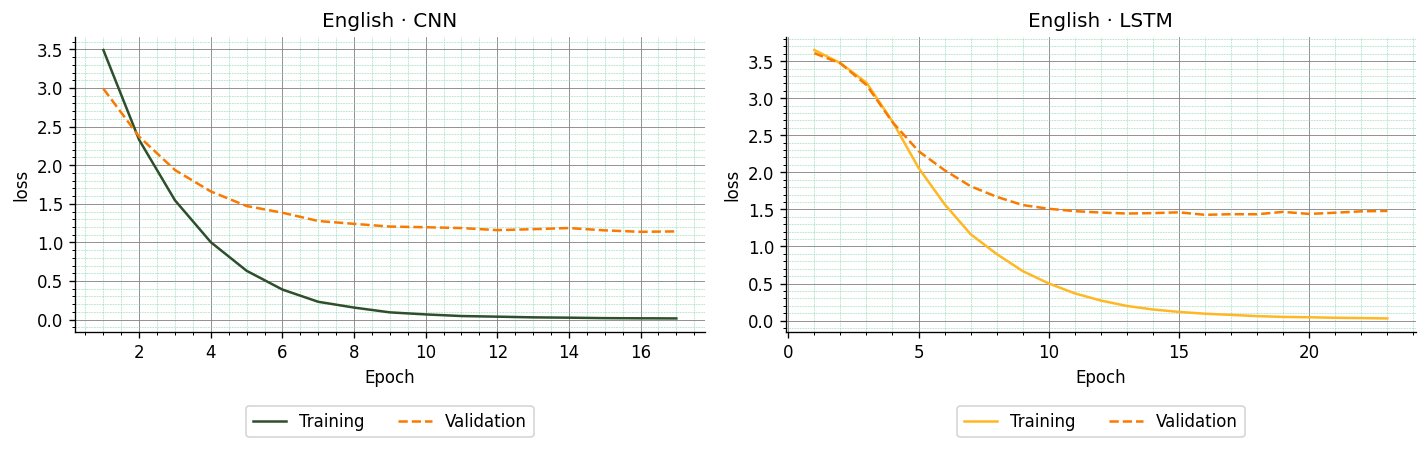

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, MODEL_CLASSES):
    h = histories[('eng', name)]
    ax.plot(h.epoch, h['train_loss'], label='Training', color=MODEL_COLORS[name])
    ax.plot(h.epoch, h['val_loss'], label='Validation', color=NATURE[6], linestyle='--')
    ax.set(title=f'English · {name}', xlabel='Epoch', ylabel='loss')
    ax.legend()
finish(fig, 'eng_loss_curves')

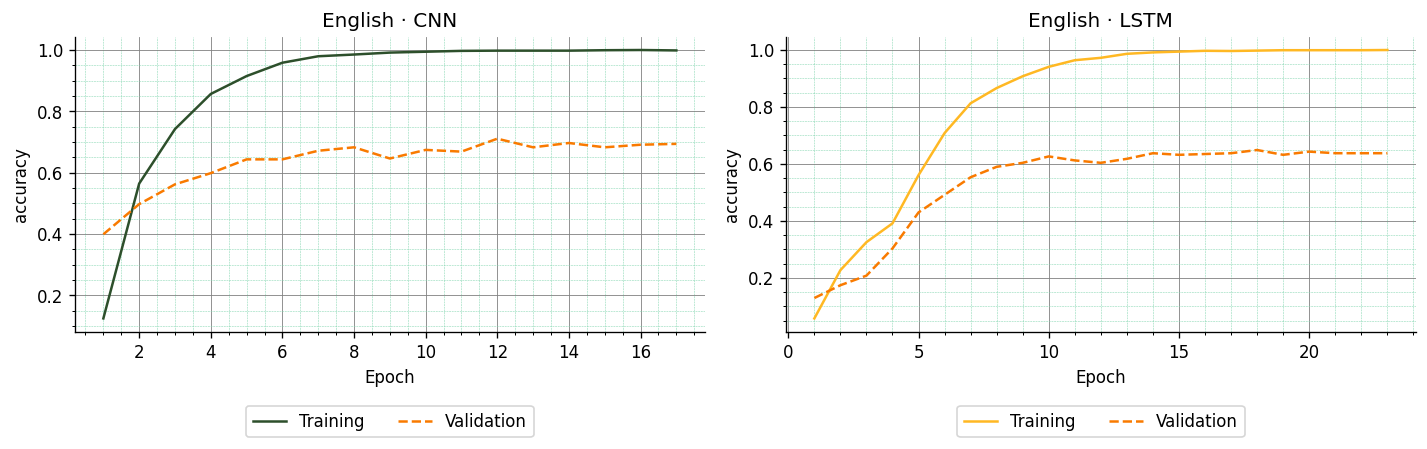

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, MODEL_CLASSES):
    h = histories[('eng', name)]
    ax.plot(h.epoch, h['train_accuracy'], label='Training', color=MODEL_COLORS[name])
    ax.plot(h.epoch, h['val_accuracy'], label='Validation', color=NATURE[6], linestyle='--')
    ax.set(title=f'English · {name}', xlabel='Epoch', ylabel='accuracy')
    ax.legend()
finish(fig, 'eng_accuracy_curves')


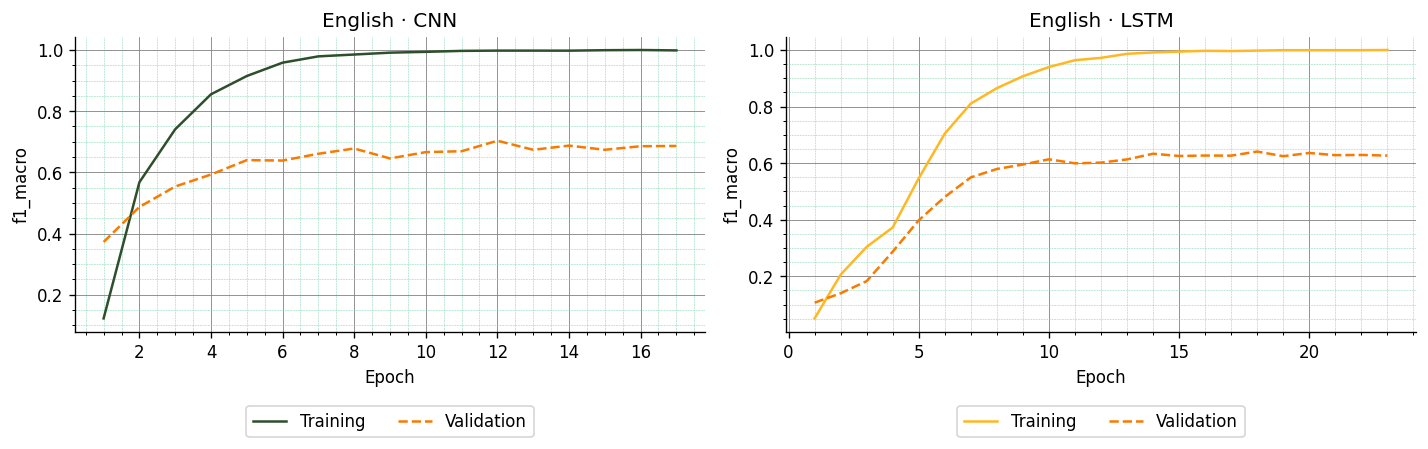

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, MODEL_CLASSES):
    h = histories[('eng', name)]
    ax.plot(h.epoch, h['train_f1_macro'], label='Training', color=MODEL_COLORS[name])
    ax.plot(h.epoch, h['val_f1_macro'], label='Validation', color=NATURE[6], linestyle='--')
    ax.set(title=f'English · {name}', xlabel='Epoch', ylabel='f1_macro')
    ax.legend()
finish(fig, 'eng_f1_macro_curves')


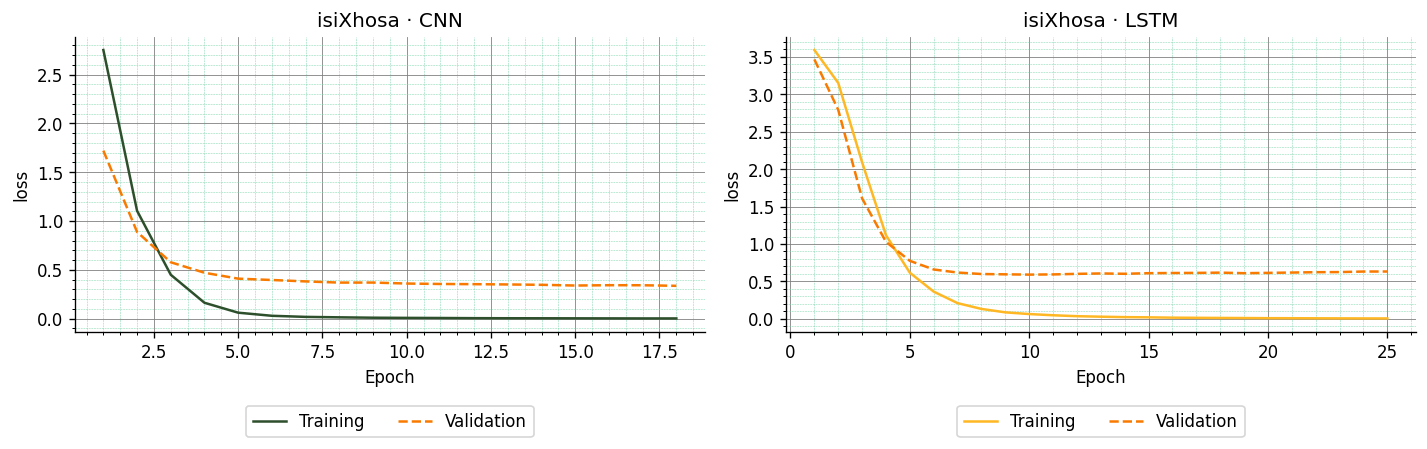

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, MODEL_CLASSES):
    h = histories[('xho', name)]
    ax.plot(h.epoch, h['train_loss'], label='Training', color=MODEL_COLORS[name])
    ax.plot(h.epoch, h['val_loss'], label='Validation', color=NATURE[6], linestyle='--')
    ax.set(title=f'isiXhosa · {name}', xlabel='Epoch', ylabel='loss')
    ax.legend()
finish(fig, 'xho_loss_curves')


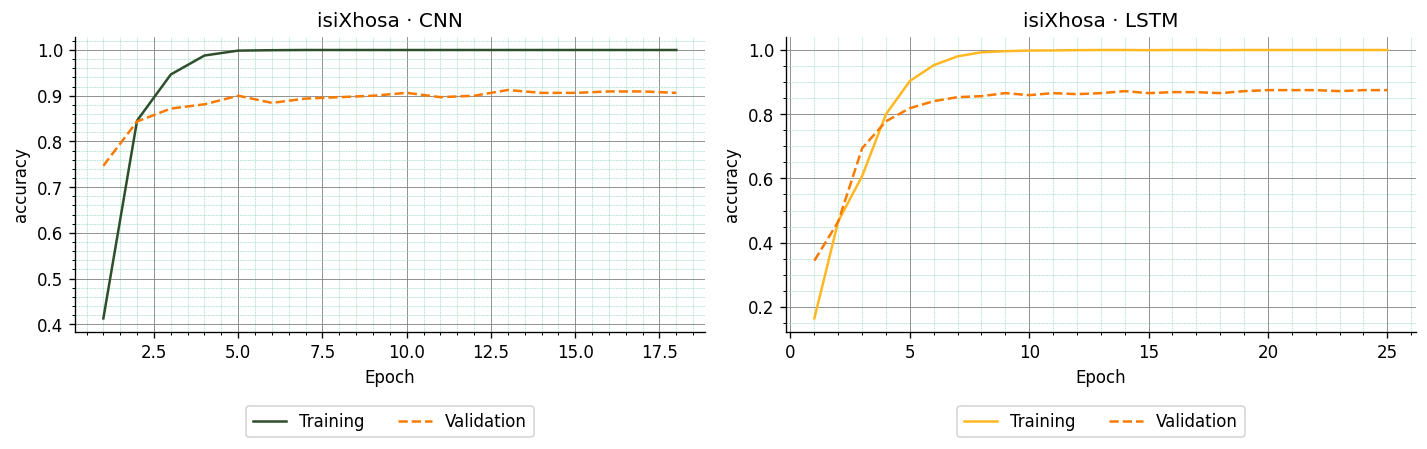

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, MODEL_CLASSES):
    h = histories[('xho', name)]
    ax.plot(h.epoch, h['train_accuracy'], label='Training', color=MODEL_COLORS[name])
    ax.plot(h.epoch, h['val_accuracy'], label='Validation', color=NATURE[6], linestyle='--')
    ax.set(title=f'isiXhosa · {name}', xlabel='Epoch', ylabel='accuracy')
    ax.legend()
finish(fig, 'xho_accuracy_curves')


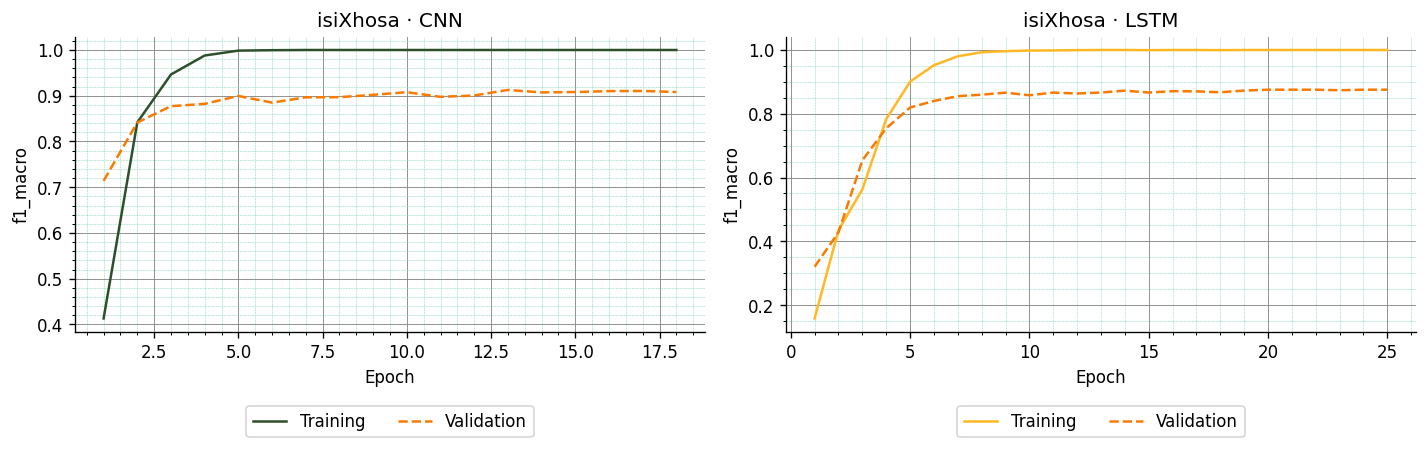

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, MODEL_CLASSES):
    h = histories[('xho', name)]
    ax.plot(h.epoch, h['train_f1_macro'], label='Training', color=MODEL_COLORS[name])
    ax.plot(h.epoch, h['val_f1_macro'], label='Validation', color=NATURE[6], linestyle='--')
    ax.set(title=f'isiXhosa · {name}', xlabel='Epoch', ylabel='f1_macro')
    ax.legend()
finish(fig, 'xho_f1_macro_curves')


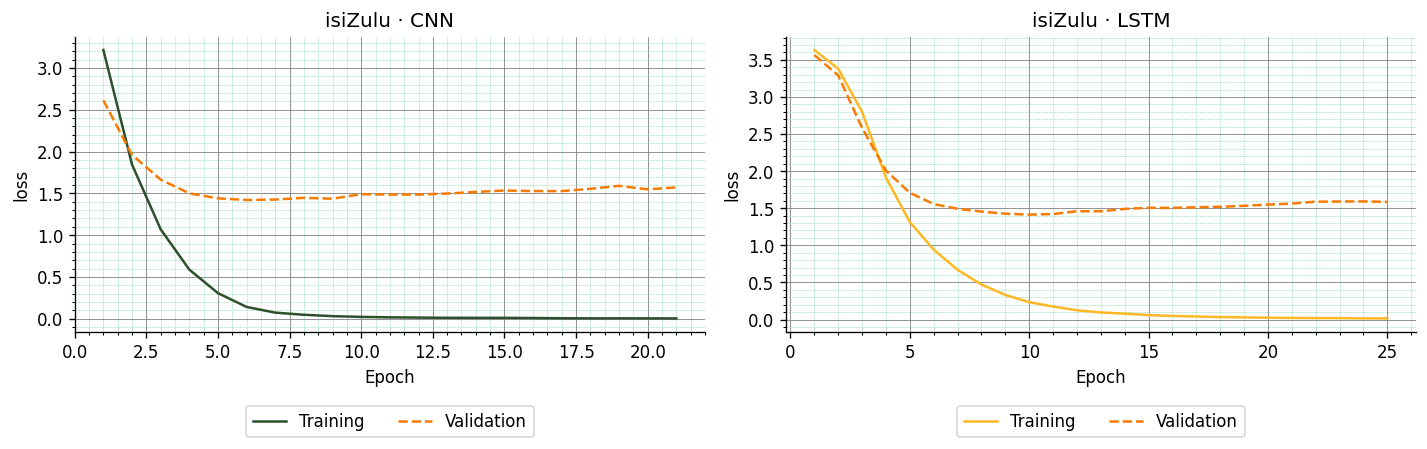

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, MODEL_CLASSES):
    h = histories[('zul', name)]
    ax.plot(h.epoch, h['train_loss'], label='Training', color=MODEL_COLORS[name])
    ax.plot(h.epoch, h['val_loss'], label='Validation', color=NATURE[6], linestyle='--')
    ax.set(title=f'isiZulu · {name}', xlabel='Epoch', ylabel='loss')
    ax.legend()
finish(fig, 'zul_loss_curves')


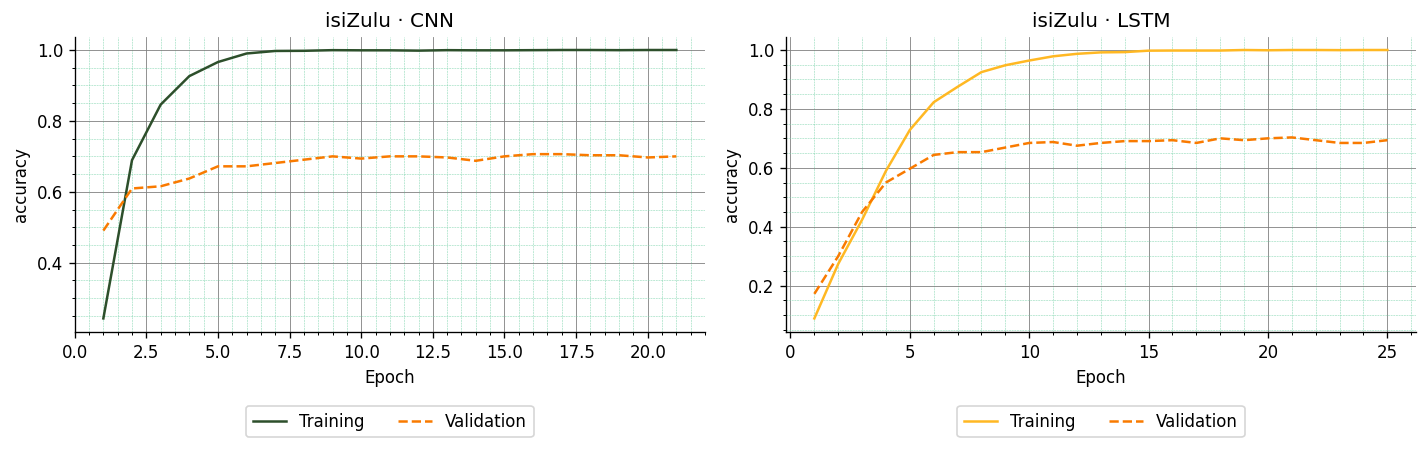

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, MODEL_CLASSES):
    h = histories[('zul', name)]
    ax.plot(h.epoch, h['train_accuracy'], label='Training', color=MODEL_COLORS[name])
    ax.plot(h.epoch, h['val_accuracy'], label='Validation', color=NATURE[6], linestyle='--')
    ax.set(title=f'isiZulu · {name}', xlabel='Epoch', ylabel='accuracy')
    ax.legend()
finish(fig, 'zul_accuracy_curves')


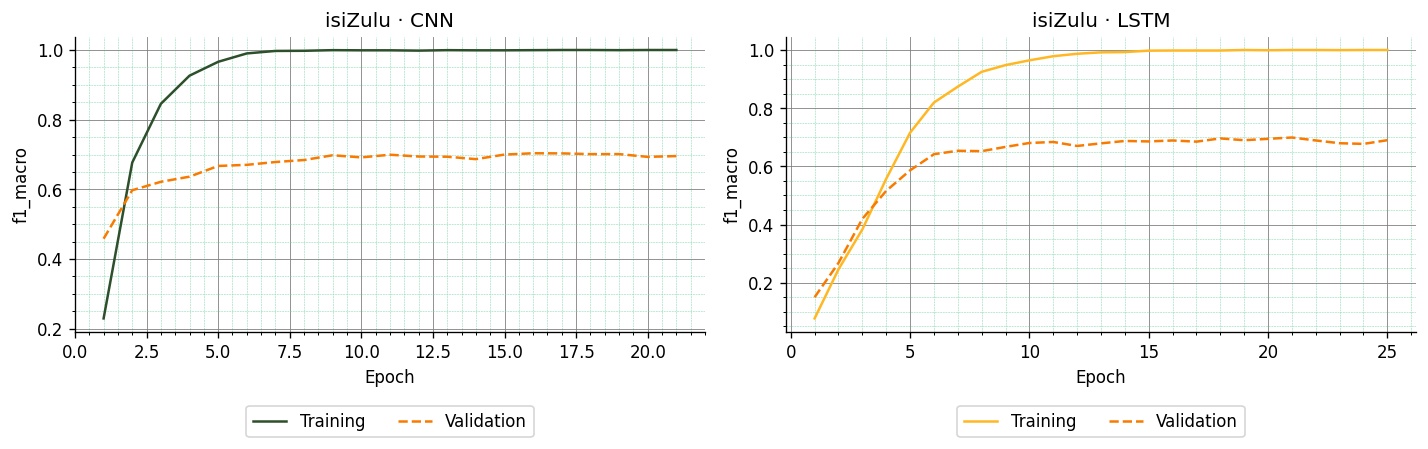

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, MODEL_CLASSES):
    h = histories[('zul', name)]
    ax.plot(h.epoch, h['train_f1_macro'], label='Training', color=MODEL_COLORS[name])
    ax.plot(h.epoch, h['val_f1_macro'], label='Validation', color=NATURE[6], linestyle='--')
    ax.set(title=f'isiZulu · {name}', xlabel='Epoch', ylabel='f1_macro')
    ax.legend()
finish(fig, 'zul_f1_macro_curves')


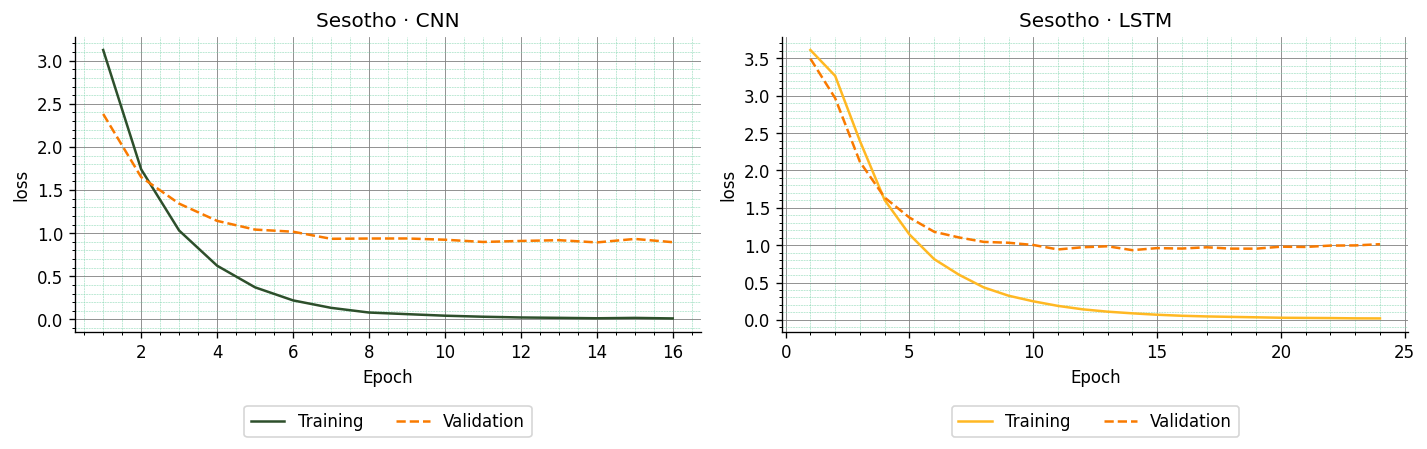

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, MODEL_CLASSES):
    h = histories[('sot', name)]
    ax.plot(h.epoch, h['train_loss'], label='Training', color=MODEL_COLORS[name])
    ax.plot(h.epoch, h['val_loss'], label='Validation', color=NATURE[6], linestyle='--')
    ax.set(title=f'Sesotho · {name}', xlabel='Epoch', ylabel='loss')
    ax.legend()
finish(fig, 'sot_loss_curves')


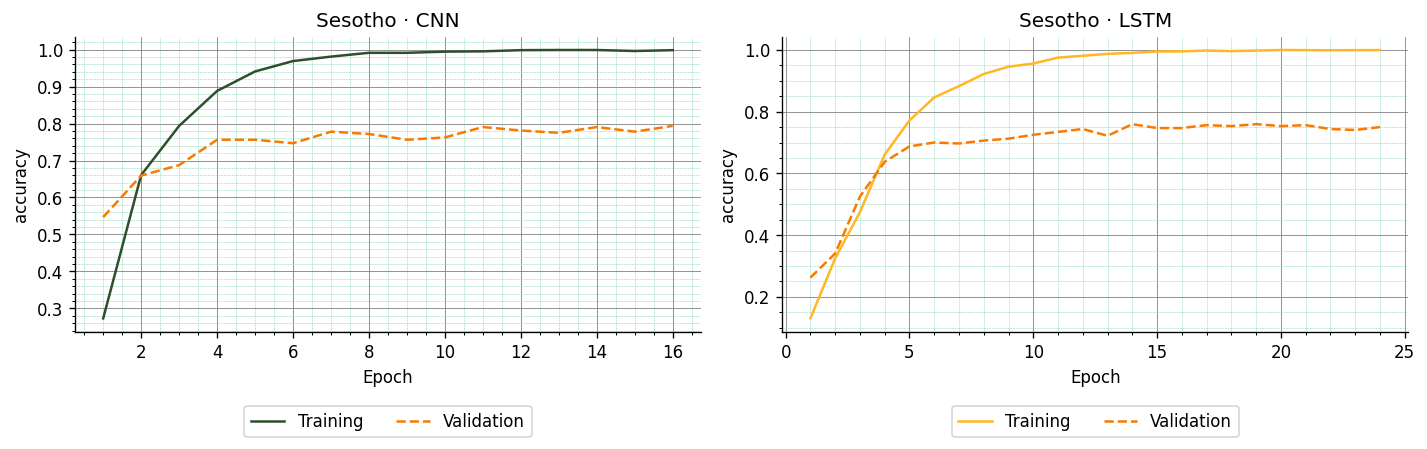

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, MODEL_CLASSES):
    h = histories[('sot', name)]
    ax.plot(h.epoch, h['train_accuracy'], label='Training', color=MODEL_COLORS[name])
    ax.plot(h.epoch, h['val_accuracy'], label='Validation', color=NATURE[6], linestyle='--')
    ax.set(title=f'Sesotho · {name}', xlabel='Epoch', ylabel='accuracy')
    ax.legend()
finish(fig, 'sot_accuracy_curves')


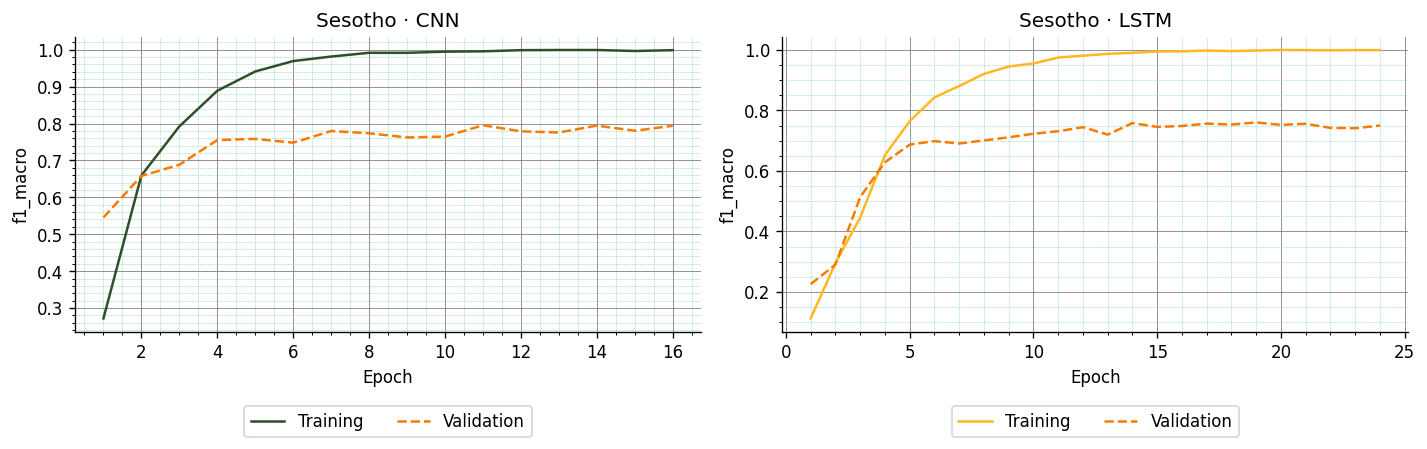

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, MODEL_CLASSES):
    h = histories[('sot', name)]
    ax.plot(h.epoch, h['train_f1_macro'], label='Training', color=MODEL_COLORS[name])
    ax.plot(h.epoch, h['val_f1_macro'], label='Validation', color=NATURE[6], linestyle='--')
    ax.set(title=f'Sesotho · {name}', xlabel='Epoch', ylabel='f1_macro')
    ax.legend()
finish(fig, 'sot_f1_macro_curves')


### Held-out test evaluation and efficiency
We are going to evaluate the selected checkpoints on each language's same test split. Save all class reports and per-utterance predictions. Parameter count and state-dictionary size describe model footprint. Latency is the median over 30 warmed-up **batch-size-one** forward passes on the same first test example within each language, excluding tokenization, transfer and disk access; synchronize CUDA before and after timing. This is a controlled model-only measurement, not application end-to-end latency or a whole-dataset average.

In [53]:
def load_model(lang,name):
    model=new_model(lang,name)
    model.load_state_dict(torch.load(OUT / f'{lang}_{name}.pt',map_location=DEVICE,weights_only=True))
    return model.eval()

In [54]:
def sync():
    if DEVICE.type=='cuda': torch.cuda.synchronize()


In [55]:
def latency_ms(model, sample):
    x,lengths,_=collate([sample]); x=x.to(DEVICE)
    with torch.inference_mode():
        for _ in range(10): model(x,lengths)
        sync(); times=[]
        for _ in range(30):
            sync(); start=time.perf_counter(); model(x,lengths); sync()
            times.append((time.perf_counter()-start)*1000)
    return float(np.median(times))


### Evaluate all eight models
Save class reports and predictions, and measure footprint and latency.


In [56]:
rows=[]; predictions={}
for lang in LANGUAGES:
    art=artifacts[lang]
    for name in MODEL_CLASSES:
        model=load_model(lang,name)
        weights=art['weights'].to(DEVICE) if CFG['use_class_weights'] else None
        score,y,pred=run_epoch(model,make_loaders(lang)['test'],weights)
        report=classification_report(y,pred,labels=list(range(len(art['labels']))),target_names=art['labels'],output_dict=True,zero_division=0)
        pd.DataFrame(report).T.to_csv(OUT / f'{lang}_{name}_classification_report.csv')
        table=data[lang]['test'][['text','intent']].copy()
        table['predicted_intent']=[art['labels'][i] for i in pred]
        table.to_csv(OUT / f'{lang}_{name}_predictions.csv',index=False)
        predictions[(lang,name)]=table
        rows.append(dict(language=lang,model=name,**score,
            parameters=sum(p.numel() for p in model.parameters()),
            size_mb=(OUT / f'{lang}_{name}.pt').stat().st_size/(1024**2),
            latency_ms=latency_ms(model,IntentDataset(data[lang]['test'],art)[0])))


In [57]:
results=pd.DataFrame(rows)
results.to_csv(OUT / 'model_comparison.csv',index=False)
display(results.round(4))


,language,model,loss,accuracy,precision_macro,recall_macro,f1_macro,parameters,size_mb,latency_ms
0,eng,CNN,0.2095,0.9469,0.9503,0.9467,0.9467,517928,1.9790,8.8520
1,eng,LSTM,0.2724,0.9405,0.9462,0.9408,0.9411,442792,1.6918,8.5487
2,xho,CNN,0.4880,0.8641,0.8853,0.8641,0.8644,699432,2.6714,4.2147
3,xho,LSTM,0.6993,0.8453,0.8956,0.8453,0.8503,624296,2.3842,2.6513
4,zul,CNN,1.1733,0.7156,0.7614,0.7156,0.7096,933672,3.5649,4.8462
5,zul,LSTM,1.2958,0.6984,0.7180,0.6984,0.6835,858536,3.2777,2.5358
6,sot,CNN,0.8582,0.7703,0.7882,0.7703,0.7688,529320,2.0225,4.9551
7,sot,LSTM,1.0110,0.7547,0.7681,0.7547,0.7553,454184,1.7353,2.4953


### Model comparisons
We are going to compare CNN against LSTM **within each language** first. Cross-language differences also reflect data sizes, label support, writing conventions and unknown-token rates. Language averages weight each language equally and are descriptive; they are not a pooled multilingual test score. Test rankings below are retrospective summaries, not checkpoint selection.

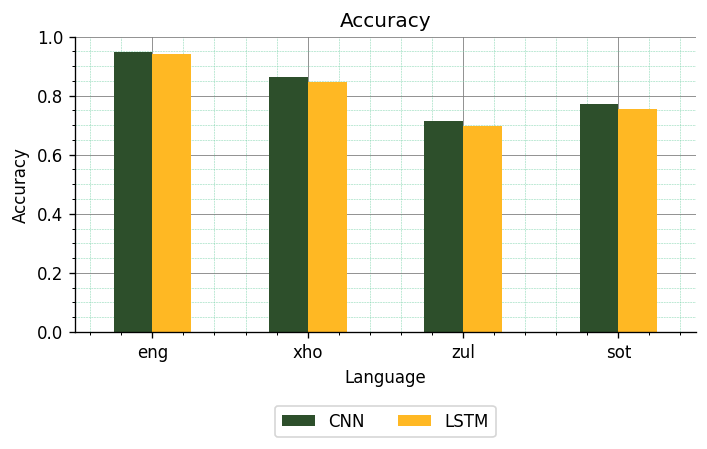

In [58]:
fig, ax = plt.subplots(figsize=(6, 4))
comparison = results.pivot(index='language', columns='model', values='accuracy')
comparison.reindex(LANGUAGES)[['CNN', 'LSTM']].plot.bar(
    ax=ax, rot=0, color=[MODEL_COLORS['CNN'], MODEL_COLORS['LSTM']])
ax.set(title='Accuracy', xlabel='Language', ylabel='Accuracy')
ax.set_ylim(0, 1)
finish(fig, 'accuracy_comparison')


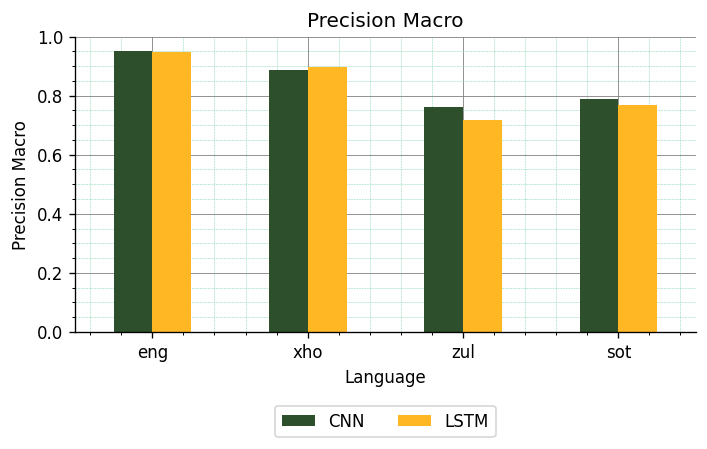

In [59]:
fig, ax = plt.subplots(figsize=(6, 4))
comparison = results.pivot(index='language', columns='model', values='precision_macro')
comparison.reindex(LANGUAGES)[['CNN', 'LSTM']].plot.bar(
    ax=ax, rot=0, color=[MODEL_COLORS['CNN'], MODEL_COLORS['LSTM']])
ax.set(title='Precision Macro', xlabel='Language', ylabel='Precision Macro')
ax.set_ylim(0, 1)
finish(fig, 'precision_macro_comparison')


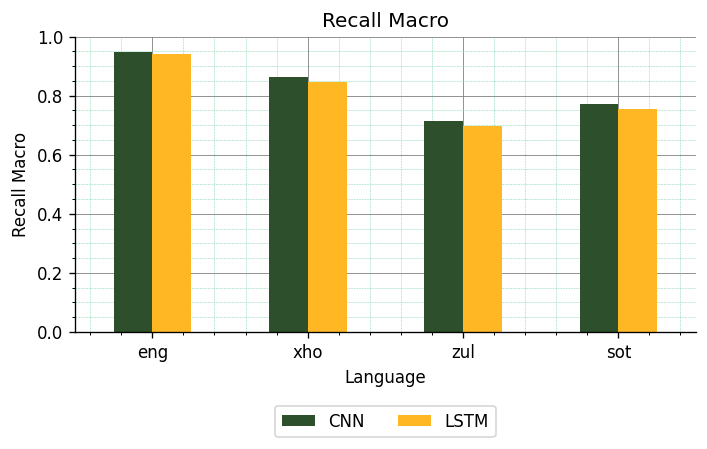

In [60]:
fig, ax = plt.subplots(figsize=(6, 4))
comparison = results.pivot(index='language', columns='model', values='recall_macro')
comparison.reindex(LANGUAGES)[['CNN', 'LSTM']].plot.bar(
    ax=ax, rot=0, color=[MODEL_COLORS['CNN'], MODEL_COLORS['LSTM']])
ax.set(title='Recall Macro', xlabel='Language', ylabel='Recall Macro')
ax.set_ylim(0, 1)
finish(fig, 'recall_macro_comparison')


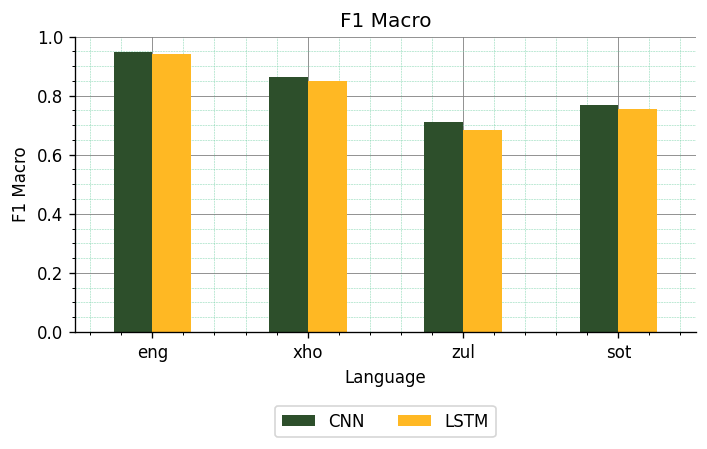

In [61]:
fig, ax = plt.subplots(figsize=(6, 4))
comparison = results.pivot(index='language', columns='model', values='f1_macro')
comparison.reindex(LANGUAGES)[['CNN', 'LSTM']].plot.bar(
    ax=ax, rot=0, color=[MODEL_COLORS['CNN'], MODEL_COLORS['LSTM']])
ax.set(title='F1 Macro', xlabel='Language', ylabel='F1 Macro')
ax.set_ylim(0, 1)
finish(fig, 'f1_macro_comparison')


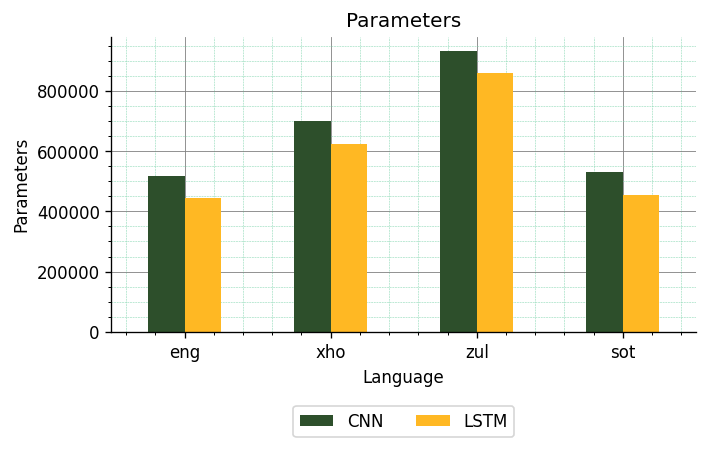

In [62]:
fig, ax = plt.subplots(figsize=(6, 4))
comparison = results.pivot(index='language', columns='model', values='parameters')
comparison.reindex(LANGUAGES)[['CNN', 'LSTM']].plot.bar(
    ax=ax, rot=0, color=[MODEL_COLORS['CNN'], MODEL_COLORS['LSTM']])
ax.set(title='Parameters', xlabel='Language', ylabel='Parameters')
finish(fig, 'parameters_comparison')


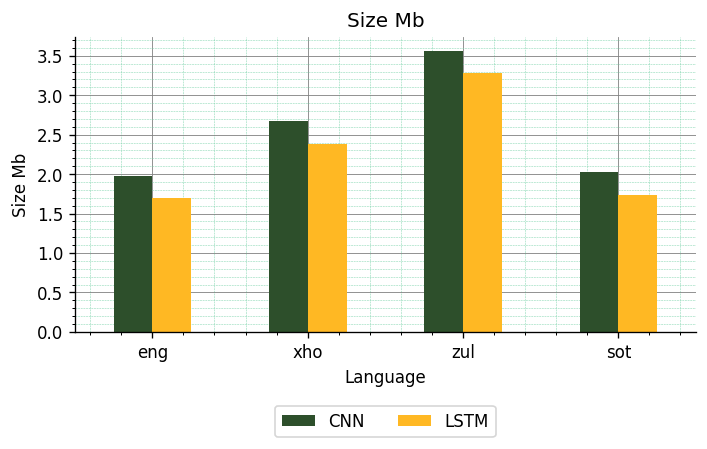

In [63]:
fig, ax = plt.subplots(figsize=(6, 4))
comparison = results.pivot(index='language', columns='model', values='size_mb')
comparison.reindex(LANGUAGES)[['CNN', 'LSTM']].plot.bar(
    ax=ax, rot=0, color=[MODEL_COLORS['CNN'], MODEL_COLORS['LSTM']])
ax.set(title='Size Mb', xlabel='Language', ylabel='Size Mb')
finish(fig, 'size_mb_comparison')


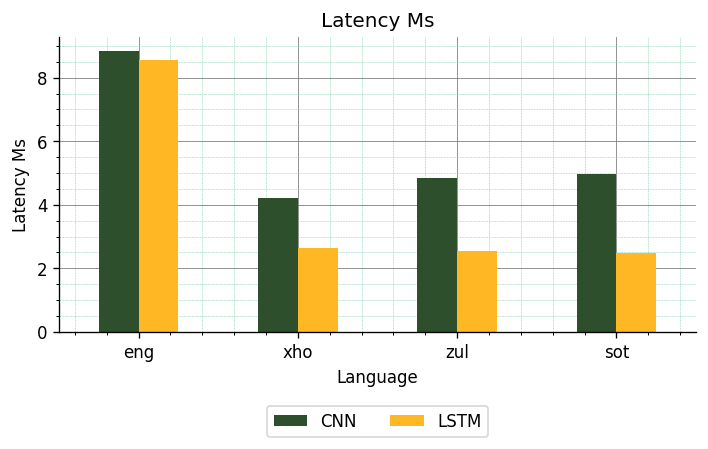

In [64]:
fig, ax = plt.subplots(figsize=(6, 4))
comparison = results.pivot(index='language', columns='model', values='latency_ms')
comparison.reindex(LANGUAGES)[['CNN', 'LSTM']].plot.bar(
    ax=ax, rot=0, color=[MODEL_COLORS['CNN'], MODEL_COLORS['LSTM']])
ax.set(title='Latency Ms', xlabel='Language', ylabel='Latency Ms')
finish(fig, 'latency_ms_comparison')


### Average model performance across languages
In the following code cell we are going to give each language equal weight; this is a descriptive average, not a pooled test score.


In [65]:
display(results.groupby('model')[['accuracy','precision_macro','recall_macro','f1_macro']].mean().round(4))

,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
CNN,0.8242,0.8463,0.8242,0.8224
LSTM,0.8097,0.8320,0.8098,0.8076


### Compare paired macro F1 differences
In the following code cell we are going to compare positive differences favor CNN; negative differences favor LSTM.


In [66]:
paired = results.pivot(index='language', columns='model', values='f1_macro')
paired['CNN minus LSTM (percentage points)'] = 100 * (paired.CNN - paired.LSTM)
display(paired.round(4))

model,CNN,LSTM,CNN minus LSTM (percentage points)
language,,,
eng,0.9467,0.9411,0.5599
sot,0.7688,0.7553,1.3485
xho,0.8644,0.8503,1.4093
zul,0.7096,0.6835,2.6076


### Word-masking explanations
For a tokenized utterance $x$, we fix the original predicted class $c^*$. We replace only token position $i$ with the existing `<UNK>` token; keep every position and length unchanged. Importance is the resulting probability drop:
$$
c^*=\arg\max_c p(c\mid x),\qquad
I_i=p(c^*\mid x)-p(c^*\mid x^{(i\rightarrow\mathrm{UNK})})
$$
A positive score means this token supports the original prediction under this perturbation; a negative score means replacement increases its probability. The target class stays fixed even if the masked prediction changes. Repeated words are masked one occurrence at a time. Tokens already mapped to `<UNK>` get zero because the input is unchanged.

This is **post-hoc token occlusion**, not masked-language-model training, attention or a causal explanation. `<UNK>` may be poorly learned when few training tokens are unknown, and masked sequences may be unnatural. Interactions mean individual scores need not add up. Explanations apply only to tokens retained after truncation; morphological pieces within a token cannot be distinguished. Padding masks in CNN pooling and packed LSTM batching serve a different purpose: excluding artificial trailing padding.

The first test utterance in each language is used for both architectures, avoiding hand-picking only successful predictions. Titles report each model's prediction; tables show the true intent and any prediction changes after masking.


### Compute token occlusion scores
In the following code cell we are going to Mask one retained token position at a time and keep the original predicted class fixed.

In [67]:
@torch.inference_mode()
def explain(lang,name,text):
    art=artifacts[lang]; model=load_model(lang,name)
    tokens=tokenize(text)[:art['max_len']]
    if not tokens: raise ValueError('Enter at least one word or number.')
    ids=torch.tensor([art['vocab'].get(w,1) for w in tokens],dtype=torch.long)
    sequences=[ids.clone() for _ in range(len(ids)+1)]
    for i in range(len(ids)): sequences[i+1][i]=1
    x,lengths,_=collate([(seq,0) for seq in sequences])
    probs=model(x.to(DEVICE),lengths).softmax(1).cpu()
    target=int(probs[0].argmax()); base=float(probs[0,target])
    frame=pd.DataFrame({'position':range(1,len(tokens)+1),'token':tokens,
        'already_unknown':ids.eq(1).tolist(),
        'masked_probability':probs[1:,target].tolist(),
        'importance':(probs[0,target]-probs[1:,target]).tolist(),
        'masked_prediction':[art['labels'][i] for i in probs[1:].argmax(1).tolist()]})
    return art['labels'][target],base,frame


In [68]:
example = data['eng']['test'].iloc[0]
print(f'Text: {example.text} | True intent: {example.intent}')
masking_eng = {}
for name in MODEL_CLASSES:
    label, prob, frame = explain('eng', name, example.text)
    masking_eng[name] = (label, prob, frame)
    frame.to_csv(OUT / f'eng_{name}_masking.csv', index=False)
    print(name, '| Predicted intent:', label, '| Probability:', round(prob, 4))
    display(frame)

Text: Wake me up early at 6:00 AM because we are going to Church in the morning | True intent: alarm
CNN | Predicted intent: alarm | Probability: 0.9929


,position,token,already_unknown,masked_probability,importance,masked_prediction
0,1,wake,False,0.954093,0.038840,alarm
1,2,me,False,0.894678,0.098255,alarm
2,3,up,False,0.804572,0.188361,alarm
3,4,early,False,0.983052,0.009880,alarm
4,5,at,False,0.938299,0.054634,alarm
5,6,6,False,0.965394,0.027538,alarm
6,7,00,False,0.964174,0.028758,alarm
7,8,am,False,0.981878,0.011054,alarm
8,9,because,False,0.957926,0.035007,alarm
9,10,we,False,0.982348,0.010585,alarm


LSTM | Predicted intent: alarm | Probability: 0.9639


,position,token,already_unknown,masked_probability,importance,masked_prediction
0,1,wake,False,0.936265,0.027647,alarm
1,2,me,False,0.848658,0.115255,alarm
2,3,up,False,0.300480,0.663432,alarm
3,4,early,False,0.864597,0.099315,alarm
4,5,at,False,0.302859,0.661053,food_last
5,6,6,False,0.865517,0.098395,alarm
6,7,00,False,0.928005,0.035907,alarm
7,8,am,False,0.947165,0.016747,alarm
8,9,because,False,0.945791,0.018122,alarm
9,10,we,False,0.960464,0.003448,alarm


### English CNN: plot word-masking importance
Show up to 20 positions with the largest absolute changes. Positive bars support the original prediction under this perturbation.


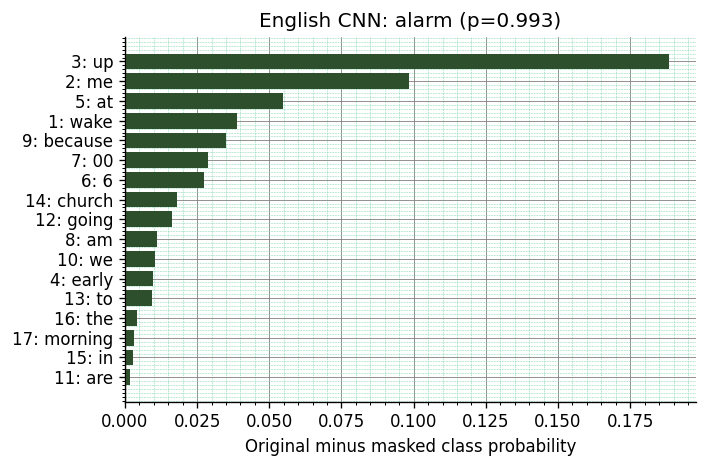

In [69]:
label, prob, frame = masking_eng['CNN']
view = frame.sort_values('importance', key=lambda s: s.abs(), ascending=False).head(20)
view = view.sort_values('importance')
fig, ax = plt.subplots(figsize=(6, 4))
colors = [NATURE[0] if value >= 0 else NATURE[2] for value in view.importance]
ax.barh([f'{i}: {w}' for i, w in zip(view.position, view.token)], view.importance, color=colors)
ax.axvline(0, color=NATURE[9], linewidth=0.8)
ax.set(title=f'English CNN: {label} (p={prob:.3f})',
       xlabel='Original minus masked class probability')
finish(fig, 'eng_CNN_word_masking')


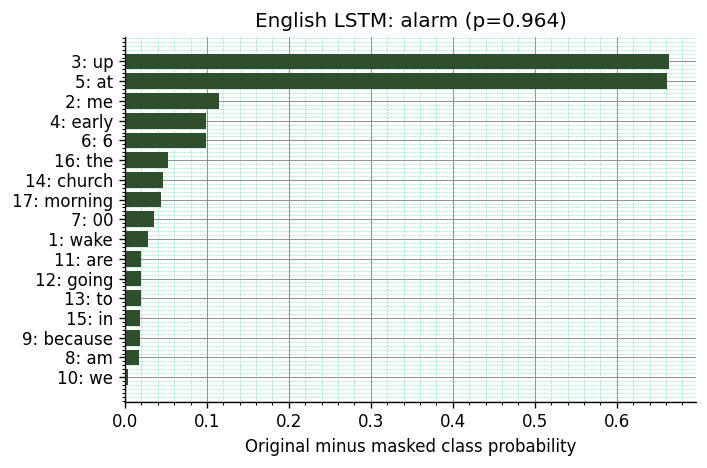

In [70]:
label, prob, frame = masking_eng['LSTM']
view = frame.sort_values('importance', key=lambda s: s.abs(), ascending=False).head(20)
view = view.sort_values('importance')
fig, ax = plt.subplots(figsize=(6, 4))
colors = [NATURE[0] if value >= 0 else NATURE[2] for value in view.importance]
ax.barh([f'{i}: {w}' for i, w in zip(view.position, view.token)], view.importance, color=colors)
ax.axvline(0, color=NATURE[9], linewidth=0.8)
ax.set(title=f'English LSTM: {label} (p={prob:.3f})',
       xlabel='Original minus masked class probability')
finish(fig, 'eng_LSTM_word_masking')


In [71]:
example = data['xho']['test'].iloc[0]
print(f'Text: {example.text} | True intent: {example.intent}')
masking_xho = {}
for name in MODEL_CLASSES:
    label, prob, frame = explain('xho', name, example.text)
    masking_xho[name] = (label, prob, frame)
    frame.to_csv(OUT / f'xho_{name}_masking.csv', index=False)
    print(name, '| Predicted intent:', label, '| Probability:', round(prob, 4))
    display(frame)


Text: Nceda usete i-alam ka-5 Ngecawe emva kwemini.  | True intent: alarm
CNN | Predicted intent: alarm | Probability: 1.0


,position,token,already_unknown,masked_probability,importance,masked_prediction
0,1,nceda,False,0.999937,0.000037,alarm
1,2,usete,False,0.999801,0.000174,alarm
2,3,i,False,0.996367,0.003607,alarm
3,4,alam,False,0.982123,0.017852,alarm
4,5,ka,False,0.998267,0.001708,alarm
5,6,5,False,0.999972,0.000003,alarm
6,7,ngecawe,False,0.999967,0.000008,alarm
7,8,emva,False,0.999923,0.000052,alarm
8,9,kwemini,False,0.999961,0.000014,alarm


LSTM | Predicted intent: alarm | Probability: 0.9995


,position,token,already_unknown,masked_probability,importance,masked_prediction
0,1,nceda,False,0.998665,0.000831,alarm
1,2,usete,False,0.998098,0.001397,alarm
2,3,i,False,0.993679,0.005816,alarm
3,4,alam,False,0.994166,0.005330,alarm
4,5,ka,False,0.999117,0.000378,alarm
5,6,5,False,0.999459,0.000036,alarm
6,7,ngecawe,False,0.999429,0.000066,alarm
7,8,emva,False,0.999241,0.000254,alarm
8,9,kwemini,False,0.998980,0.000515,alarm


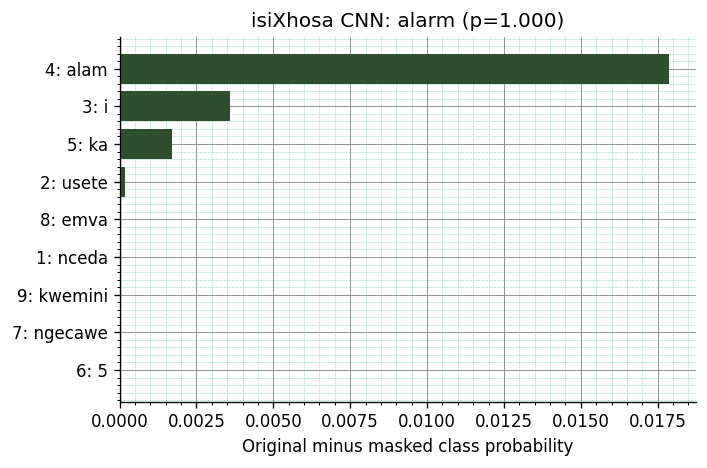

In [72]:
label, prob, frame = masking_xho['CNN']
view = frame.sort_values('importance', key=lambda s: s.abs(), ascending=False).head(20)
view = view.sort_values('importance')
fig, ax = plt.subplots(figsize=(6, 4))
colors = [NATURE[0] if value >= 0 else NATURE[2] for value in view.importance]
ax.barh([f'{i}: {w}' for i, w in zip(view.position, view.token)], view.importance, color=colors)
ax.axvline(0, color=NATURE[9], linewidth=0.8)
ax.set(title=f'isiXhosa CNN: {label} (p={prob:.3f})',
       xlabel='Original minus masked class probability')
finish(fig, 'xho_CNN_word_masking')


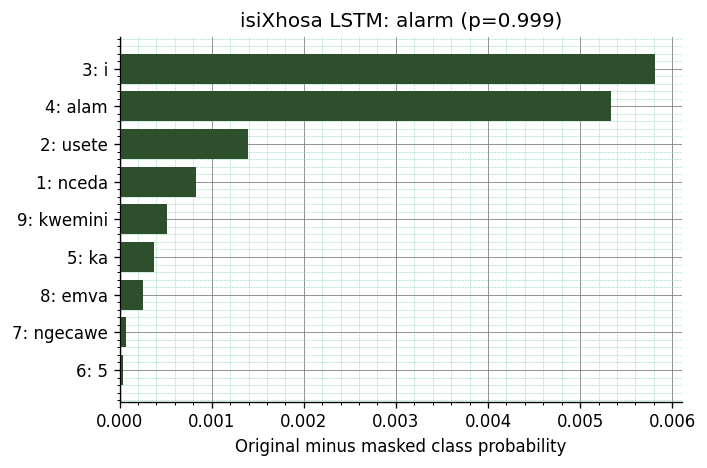

In [73]:
label, prob, frame = masking_xho['LSTM']
view = frame.sort_values('importance', key=lambda s: s.abs(), ascending=False).head(20)
view = view.sort_values('importance')
fig, ax = plt.subplots(figsize=(6, 4))
colors = [NATURE[0] if value >= 0 else NATURE[2] for value in view.importance]
ax.barh([f'{i}: {w}' for i, w in zip(view.position, view.token)], view.importance, color=colors)
ax.axvline(0, color=NATURE[9], linewidth=0.8)
ax.set(title=f'isiXhosa LSTM: {label} (p={prob:.3f})',
       xlabel='Original minus masked class probability')
finish(fig, 'xho_LSTM_word_masking')


In [74]:
example = data['zul']['test'].iloc[0]
print(f'Text: {example.text} | True intent: {example.intent}')
masking_zul = {}
for name in MODEL_CLASSES:
    label, prob, frame = explain('zul', name, example.text)
    masking_zul[name] = (label, prob, frame)
    frame.to_csv(OUT / f'zul_{name}_masking.csv', index=False)
    print(name, '| Predicted intent:', label, '| Probability:', round(prob, 4))
    display(frame)


Text: Ngivuse ngo-7 ekuseni ngosuku lwevolontiya yendawo yokukhosela izilwane. | True intent: alarm
CNN | Predicted intent: alarm | Probability: 0.9976


,position,token,already_unknown,masked_probability,importance,masked_prediction
0,1,ngivuse,False,0.981790,0.015856,alarm
1,2,ngo,False,0.725797,0.271849,alarm
2,3,7,False,0.973716,0.023930,alarm
3,4,ekuseni,False,0.815249,0.182397,alarm
4,5,ngosuku,False,0.998124,-0.000478,alarm
5,6,lwevolontiya,True,0.997646,0.000000,alarm
6,7,yendawo,False,0.996974,0.000672,alarm
7,8,yokukhosela,False,0.998346,-0.000700,alarm
8,9,izilwane,False,0.997430,0.000216,alarm


LSTM | Predicted intent: alarm | Probability: 0.9961


,position,token,already_unknown,masked_probability,importance,masked_prediction
0,1,ngivuse,False,0.963526,0.032570,alarm
1,2,ngo,False,0.960844,0.035253,alarm
2,3,7,False,0.976768,0.019329,alarm
3,4,ekuseni,False,0.919240,0.076856,alarm
4,5,ngosuku,False,0.993157,0.002940,alarm
5,6,lwevolontiya,True,0.996097,0.000000,alarm
6,7,yendawo,False,0.991808,0.004289,alarm
7,8,yokukhosela,False,0.996002,0.000095,alarm
8,9,izilwane,False,0.996891,-0.000794,alarm


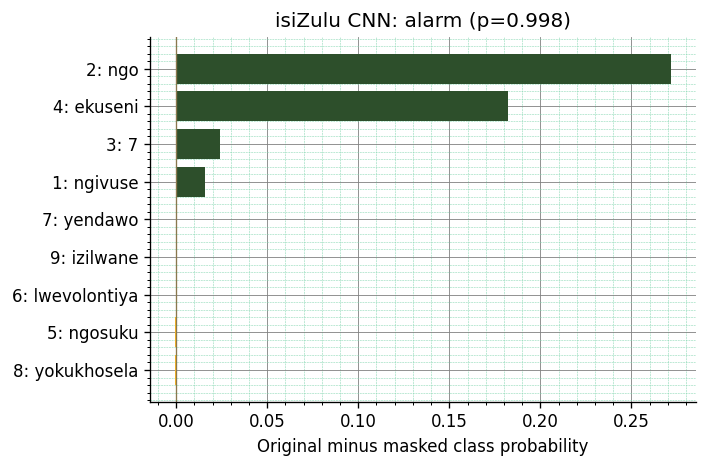

In [75]:
label, prob, frame = masking_zul['CNN']
view = frame.sort_values('importance', key=lambda s: s.abs(), ascending=False).head(20)
view = view.sort_values('importance')
fig, ax = plt.subplots(figsize=(6, 4))
colors = [NATURE[0] if value >= 0 else NATURE[2] for value in view.importance]
ax.barh([f'{i}: {w}' for i, w in zip(view.position, view.token)], view.importance, color=colors)
ax.axvline(0, color=NATURE[9], linewidth=0.8)
ax.set(title=f'isiZulu CNN: {label} (p={prob:.3f})',
       xlabel='Original minus masked class probability')
finish(fig, 'zul_CNN_word_masking')


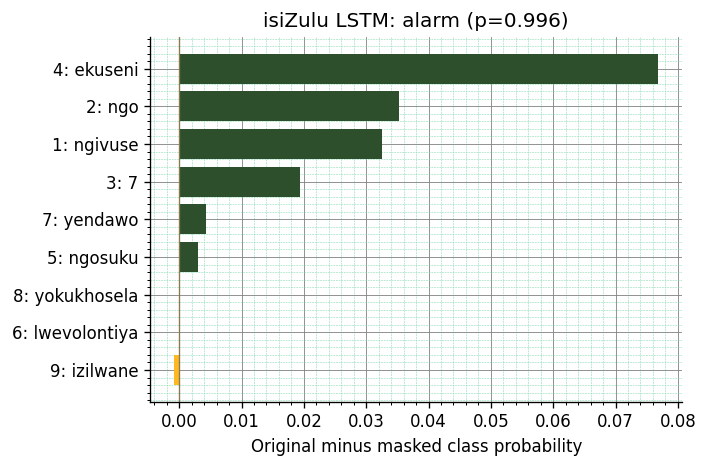

In [76]:
label, prob, frame = masking_zul['LSTM']
view = frame.sort_values('importance', key=lambda s: s.abs(), ascending=False).head(20)
view = view.sort_values('importance')
fig, ax = plt.subplots(figsize=(6, 4))
colors = [NATURE[0] if value >= 0 else NATURE[2] for value in view.importance]
ax.barh([f'{i}: {w}' for i, w in zip(view.position, view.token)], view.importance, color=colors)
ax.axvline(0, color=NATURE[9], linewidth=0.8)
ax.set(title=f'isiZulu LSTM: {label} (p={prob:.3f})',
       xlabel='Original minus masked class probability')
finish(fig, 'zul_LSTM_word_masking')


In [77]:
example = data['sot']['test'].iloc[0]
print(f'Text: {example.text} | True intent: {example.intent}')
masking_sot = {}
for name in MODEL_CLASSES:
    label, prob, frame = explain('sot', name, example.text)
    masking_sot[name] = (label, prob, frame)
    frame.to_csv(OUT / f'sot_{name}_masking.csv', index=False)
    print(name, '| Predicted intent:', label, '| Probability:', round(prob, 4))
    display(frame)


Text: O ntsose ka 4 hoseng | True intent: alarm
CNN | Predicted intent: alarm | Probability: 0.5866


,position,token,already_unknown,masked_probability,importance,masked_prediction
0,1,o,False,0.325728,0.260830,alarm
1,2,ntsose,False,0.470535,0.116022,alarm
2,3,ka,False,0.732304,-0.145747,alarm
3,4,4,False,0.654523,-0.067965,alarm
4,5,hoseng,False,0.329681,0.256877,alarm


LSTM | Predicted intent: alarm | Probability: 0.9752


,position,token,already_unknown,masked_probability,importance,masked_prediction
0,1,o,False,0.949802,0.025381,alarm
1,2,ntsose,False,0.692375,0.282808,alarm
2,3,ka,False,0.960390,0.014793,alarm
3,4,4,False,0.961913,0.013270,alarm
4,5,hoseng,False,0.911234,0.063949,alarm


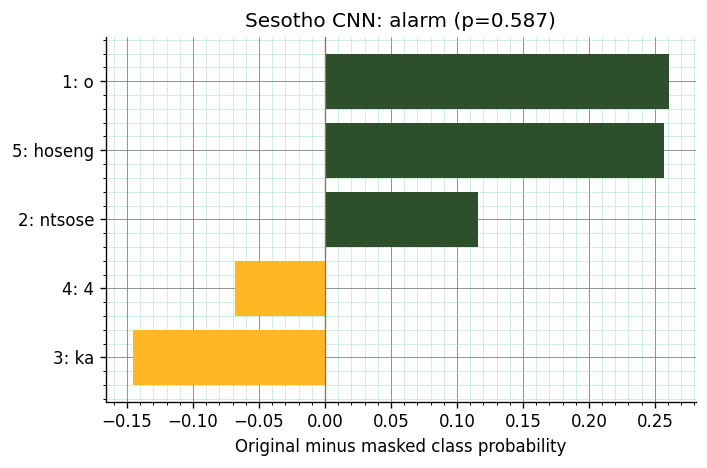

In [78]:
label, prob, frame = masking_sot['CNN']
view = frame.sort_values('importance', key=lambda s: s.abs(), ascending=False).head(20)
view = view.sort_values('importance')
fig, ax = plt.subplots(figsize=(6, 4))
colors = [NATURE[0] if value >= 0 else NATURE[2] for value in view.importance]
ax.barh([f'{i}: {w}' for i, w in zip(view.position, view.token)], view.importance, color=colors)
ax.axvline(0, color=NATURE[9], linewidth=0.8)
ax.set(title=f'Sesotho CNN: {label} (p={prob:.3f})',
       xlabel='Original minus masked class probability')
finish(fig, 'sot_CNN_word_masking')


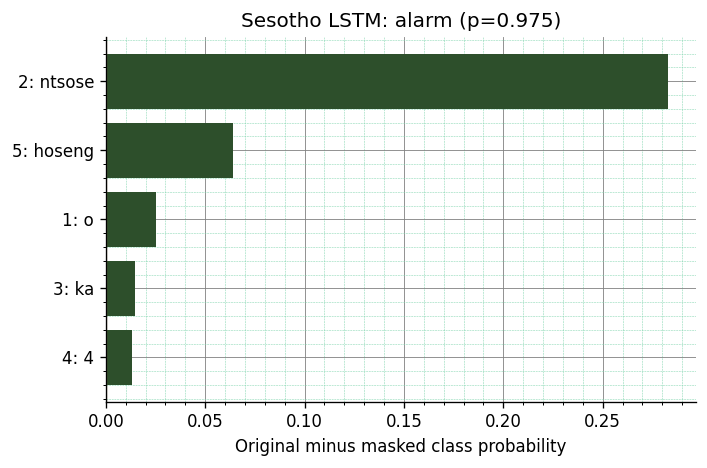

In [79]:
label, prob, frame = masking_sot['LSTM']
view = frame.sort_values('importance', key=lambda s: s.abs(), ascending=False).head(20)
view = view.sort_values('importance')
fig, ax = plt.subplots(figsize=(6, 4))
colors = [NATURE[0] if value >= 0 else NATURE[2] for value in view.importance]
ax.barh([f'{i}: {w}' for i, w in zip(view.position, view.token)], view.importance, color=colors)
ax.axvline(0, color=NATURE[9], linewidth=0.8)
ax.set(title=f'Sesotho LSTM: {label} (p={prob:.3f})',
       xlabel='Original minus masked class probability')
finish(fig, 'sot_LSTM_word_masking')


### Inspecting mistakes


In [80]:
for lang in LANGUAGES:
    for name in MODEL_CLASSES:
        table=predictions[(lang,name)]
        errors=table[table.intent!=table.predicted_intent]
        print(f'{lang}/{name}: {len(errors)} errors out of {len(table)} test utterances')
        display(errors.head(5))
print('Outputs saved to:', OUT.resolve())

eng/CNN: 33 errors out of 622 test utterances


,text,intent,predicted_intent
16,can you please check my dasion bank account,balance,freeze_account
64,Could you reserve t2 room for us at Nourain hotel,book_hotel,restaurant_reservation
70,I wish to book Hatfield Community Hall for our...,book_hotel,book_flight
73,I need to take pizza from Pizzaman at Kaneshie...,book_hotel,book_flight
79,Can you add some time to the wednesday meeting ?,calendar_update,update_playlist


eng/LSTM: 37 errors out of 622 test utterances


,text,intent,predicted_intent
16,can you please check my dasion bank account,balance,freeze_account
45,What is my balance after paying for my DSTV bill?,bill_balance,balance
50,How much is a one way flight ticket from Newyo...,book_flight,exchange_rate
64,Could you reserve t2 room for us at Nourain hotel,book_hotel,restaurant_reservation
70,I wish to book Hatfield Community Hall for our...,book_hotel,book_flight


xho/CNN: 87 errors out of 640 test utterances


...

sot/CNN: 147 errors out of 640 test utterances


,text,intent,predicted_intent
6,Ka 7 hoseng ke kopa o time alamo,alarm,make_call
16,ke e thola jwang karata ya sekoloto?,balance,recipe
17,nka kgona ho fetola nomoro ya ka ya karata ya ...,balance,transactions
22,Ke kolota bokae sekolong,balance,bill_balance
27,Karete ya Capitec e na le bokae?,balance,bill_balance


sot/LSTM: 157 errors out of 640 test utterances


,text,intent,predicted_intent
16,ke e thola jwang karata ya sekoloto?,balance,recipe
17,nka kgona ho fetola nomoro ya ka ya karata ya ...,balance,transactions
22,Ke kolota bokae sekolong,balance,bill_balance
24,tjhelete e ka akhaontong ya hao e lekanetse di...,balance,freeze_account
25,Tjhelete e ka akhaontong ya ho boloka ke bokae...,balance,pay_bill


Outputs saved to: C:\Users\crisp\Documents\PENDING PROJECTS\za\injongo_results
